# Quantum Sensor Placement — QAOA for Optimal Weather Station Placement

**Goal.** Given a set of candidate locations for weather stations and a set of zones to
monitor, select *k* stations that maximize total coverage — an instance of the NP-hard
**Maximum Coverage Problem**, solved several ways:

1. **Exact** — brute-force enumeration (ground truth) and an exact eigensolver on the QUBO.
2. **Classical heuristics** — greedy (the textbook $(1-1/e)$-approximation algorithm), LP
   relaxation + rounding, and simulated annealing on the identical QUBO QAOA solves.
3. **Penalty-based QAOA** — the budget constraint folded into the cost function as a quadratic
   penalty, compared across circuit depths (p = 1, 2, 3) with several random restarts per depth.
4. **Constraint-native QAOA** (Section 9) — the same problem, but the budget constraint is
   enforced structurally by a ring XY-mixer instead of a penalty, so every sample is feasible by
   construction. Validated numerically against the direct QUBO objective before being trusted for
   anything, and compared honestly against (3) — it is not simply better.

Results are reported as **approximation ratio** (achieved / optimal coverage) against both the
true optimum and a random-baseline floor, not raw coverage counts alone — first on a single
illustrative case study, then across a small ensemble of random instances (Section 10) so no
single method's number is read from a single lucky or unlucky map.

**Regions.** The candidate-station generator supports ten areas (`REGION` below), delivered
executed with Vienna active. For each, a handful of real, individually-sourced locations act as
anchors; the rest of the candidate pool is filled with reproducible synthetic points inside the
same bounding box — clearly labeled as such (see the `source` column).

5. **Trainability** (Section 11) — gradient-variance scaling across four ansätze vs. problem
   size and circuit depth, the direct diagnostic for the depth-dependence observed in (4).
6. **Optimizer-ansatz matching** (Section 12) — NFT vs. COBYLA on the two hardware-efficient
   ansätze, where NFT's theoretical assumption actually holds.
7. **A learned parameter predictor** (Section 13) — the literal "AI helping a quantum algorithm"
   angle: a small regressor trained to warm-start QAOA, evaluated honestly (a negative result,
   after fixing a real bug in the first version of that evaluation).
8. **Multi-angle QAOA** (Section 14) — decouples depth from parameter count within one ansatz
   family, resolving a confound Section 11 could only flag, not fix.
9. **LP-relaxation warm-starting** (Section 15) — using the same LP solution already computed in
   (2) as a structural bias on QAOA's initial state and mixer, not just as a rounded classical
   baseline.
10. **Real-hardware run** (Section 16) — circuits optimized locally, checked offline against the
    real device topology (`FakeMarrakesh`), then executed once as a single batch on `ibm_marrakesh`,
    designed to fit IBM's free-tier time budget.

**Explicitly out of scope for this version** (kept separate to avoid scope creep): real historical
weather-risk weighting, and a multi-objective formulation. See Section 17 for the full roadmap.


## 0. Setup

In [6]:
import time
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from qiskit_optimization import QuadraticProgram
from qiskit_optimization.algorithms import MinimumEigenOptimizer
from qiskit_optimization.minimum_eigensolvers import QAOA
from qiskit_algorithms.minimum_eigensolvers import NumPyMinimumEigensolver
from qiskit_algorithms.optimizers import COBYLA
from qiskit_algorithms.utils import algorithm_globals
from qiskit.primitives import StatevectorSampler, StatevectorEstimator
from qiskit.quantum_info import SparsePauliOp
from qiskit.circuit.library import QAOAAnsatz
from qiskit import QuantumCircuit, transpile
from scipy.optimize import linprog

plt.rcParams["figure.dpi"] = 110


## 1. Configuration

Each region has a `bbox` and a short list of **verified anchors** — real, named locations with
their source. Anchors were checked individually (one candidate Wikipedia coordinate for a Salerno
landmark was dropped after it turned out to be inconsistent with the location's own description —
worth checking before trusting a single source). Candidate pools are filled out to `N_STATIONS`
with reproducible synthetic points inside the bounding box when a region doesn't have enough
verified anchors on its own.

Set `CSV_PATH` to override with a real downloaded dataset (auto-detects common lat/lon column
names, or use `COLUMN_MAP`) — takes precedence over both anchors and synthetic infill.

In [7]:
# --- region presets ---
REGIONS = {
    'milano': {
        'display_name': 'Milano',
        'bbox': (45.40, 45.53, 9.05, 9.28),  # lat_min, lat_max, lon_min, lon_max
        'anchors': [
            {'name': 'Duomo', 'lat': 45.4642, 'lon': 9.1900, 'source': 'general knowledge (not individually verified)'},
            {'name': 'Stazione Centrale', 'lat': 45.4859, 'lon': 9.2044, 'source': 'general knowledge (not individually verified)'},
            {'name': 'San Siro', 'lat': 45.4781, 'lon': 9.1240, 'source': 'general knowledge (not individually verified)'},
            {'name': 'Bicocca', 'lat': 45.5150, 'lon': 9.2100, 'source': 'general knowledge (not individually verified)'},
            {'name': 'Bocconi', 'lat': 45.4505, 'lon': 9.1868, 'source': 'general knowledge (not individually verified)'},
            {'name': 'Città Studi', 'lat': 45.4780, 'lon': 9.2280, 'source': 'general knowledge (not individually verified)'},
            {'name': 'Navigli - Darsena', 'lat': 45.4515, 'lon': 9.1739, 'source': 'general knowledge (not individually verified)'},
            {'name': 'Parco Sempione', 'lat': 45.4730, 'lon': 9.1770, 'source': 'general knowledge (not individually verified)'},
            {'name': 'Certosa', 'lat': 45.5030, 'lon': 9.1450, 'source': 'general knowledge (not individually verified)'},
            {'name': 'Aeroporto di Linate', 'lat': 45.4451, 'lon': 9.2767, 'source': 'general knowledge (not individually verified)'},
            {'name': 'Famagosta', 'lat': 45.4380, 'lon': 9.1560, 'source': 'general knowledge (not individually verified)'},
            {'name': 'Lambrate', 'lat': 45.4840, 'lon': 9.2330, 'source': 'general knowledge (not individually verified)'},
        ],
    },
    'salerno': {
        'display_name': 'Salerno',
        'bbox': (40.63, 40.80, 14.70, 14.90),
        'anchors': [
            {'name': 'Stazione di Salerno', 'lat': 40.68333, 'lon': 14.76667, 'source': 'Wikipedia — Salerno railway station'},
            {'name': 'Fisciano (campus Unisa)', 'lat': 40.767, 'lon': 14.800, 'source': 'Wikipedia — Fisciano'},
        ],
    },
    'lamezia_gizzeria': {
        'display_name': 'Lamezia Terme – Gizzeria',
        'bbox': (38.88, 39.00, 16.15, 16.32),
        'anchors': [
            {'name': 'Aeroporto di Lamezia Terme (SUF)', 'lat': 38.90528, 'lon': 16.24222, 'source': "Wikipedia — Lamezia Terme International Airport"},
            {'name': 'Stazione di Lamezia Terme Centrale', 'lat': 38.92111, 'lon': 16.25556, 'source': 'Wikipedia — Lamezia Terme Centrale railway station'},
            {'name': 'Lamezia Terme (Nicastro, centro)', 'lat': 38.967, 'lon': 16.300, 'source': 'Wikipedia — Lamezia Terme'},
            {'name': 'Gizzeria (centro collinare)', 'lat': 38.98056, 'lon': 16.20556, 'source': 'Wikipedia — Gizzeria'},
            {'name': 'Lago La Vota / costa di Gizzeria', 'lat': 38.94194, 'lon': 16.18833, 'source': 'Wikipedia — La Vota Lake'},
        ],
    },
    'foligno': {
        'display_name': 'Foligno',
        'bbox': (42.90, 43.00, 12.62, 12.80),
        'anchors': [
            {'name': 'Stazione di Foligno', 'lat': 42.95444, 'lon': 12.71111, 'source': 'Wikipedia — Foligno railway station'},
            {'name': 'Piazza della Repubblica', 'lat': 42.9564, 'lon': 12.7029, 'source': 'Wikidata — Piazza della Repubblica (Foligno)'},
        ],
    },
    'rimini': {
        'display_name': 'Rimini',
        'bbox': (44.00, 44.12, 12.48, 12.62),
        'anchors': [
            {'name': 'Stazione di Rimini', 'lat': 44.06389, 'lon': 12.57400, 'source': 'Wikipedia — Rimini railway station'},
            {'name': 'Rimini Viserba', 'lat': 44.0861, 'lon': 12.5317, 'source': 'Wikidata — Rimini Viserba railway station'},
        ],
    },
    'reggio_calabria': {
        'display_name': 'Reggio Calabria',
        'bbox': (38.05, 38.16, 15.58, 15.72),
        'anchors': [
            {'name': 'Reggio Calabria (centro / Piazza Garibaldi)', 'lat': 38.11139, 'lon': 15.66194, 'source': 'Wikipedia — Reggio Calabria'},
            {'name': 'Stazione di Reggio Calabria Santa Caterina', 'lat': 38.12635, 'lon': 15.65263, 'source': 'Wikipedia — Reggio di Calabria Santa Caterina railway station'},
        ],
    },
    'vienna': {
        'display_name': 'Vienna',
        'bbox': (48.15, 48.25, 16.28, 16.46),
        'anchors': [
            {'name': 'Wien Hauptbahnhof', 'lat': 48.1867, 'lon': 16.3800, 'source': 'Wikipedia — Wien Hauptbahnhof'},
            {'name': 'Stephansplatz', 'lat': 48.2080, 'lon': 16.3716, 'source': 'Wikidata — Stephansplatz'},
            {'name': 'Wien Westbahnhof', 'lat': 48.1967, 'lon': 16.3378, 'source': 'Wikipedia — Wien Westbahnhof railway station'},
            {'name': 'Karlsplatz', 'lat': 48.2007, 'lon': 16.3689, 'source': 'Wikipedia — Karlsplatz station (Vienna U-Bahn)'},
        ],
    },
    'gstaad': {
        'display_name': 'Gstaad',
        'bbox': (46.35, 46.55, 7.20, 7.40),
        'anchors': [
            {'name': 'Gstaad (centro paese)', 'lat': 46.467, 'lon': 7.283, 'source': 'Wikipedia — Gstaad'},
            {'name': 'Gsteig bei Gstaad', 'lat': 46.383, 'lon': 7.267, 'source': 'Wikipedia — Gsteig bei Gstaad'},
            {'name': 'Rinderberg (area sciistica)', 'lat': 46.505, 'lon': 7.357, 'source': 'Wikipedia — Rinderberg'},
        ],
    },
    'zurigo': {
        'display_name': 'Zurigo',
        'bbox': (47.35, 47.48, 8.48, 8.60),
        'anchors': [
            {'name': 'Zürich Hauptbahnhof', 'lat': 47.378169, 'lon': 8.540178, 'source': 'Wikipedia — Zürich Hauptbahnhof'},
            {'name': 'ETH Zürich (Hauptgebäude)', 'lat': 47.3765, 'lon': 8.5479, 'source': 'Wikidata — ETH Zurich main building'},
            {'name': 'Aeroporto di Zurigo (ZRH)', 'lat': 47.46472, 'lon': 8.54917, 'source': 'Wikipedia — Zurich Airport'},
        ],
    },
    'losanna': {
        'display_name': 'Losanna',
        'bbox': (46.46, 46.58, 6.50, 6.70),
        'anchors': [
            {'name': 'Losanna, Gare CFF', 'lat': 46.5168, 'lon': 6.6291, 'source': 'Wikipedia — Lausanne railway station'},
            {'name': 'EPFL (Ecublens)', 'lat': 46.5222, 'lon': 6.5661, 'source': 'Wikidata — EPFL metro station'},
        ],
    },
}

REGION = 'vienna'  # 'milano' | 'salerno' | 'lamezia_gizzeria' | 'foligno' | 'rimini' | 'reggio_calabria' | 'vienna' | 'gstaad' | 'zurigo' | 'losanna'

# --- data override ---
CSV_PATH = None  # e.g. "stations.csv" — takes precedence over anchors/synthetic infill if set
COLUMN_MAP = None  # e.g. {'lat': 'Latitudine', 'lon': 'Longitudine', 'name': 'Denominazione'}

# --- problem parameters ---
N_STATIONS = 12             # total candidate stations (verified anchors + synthetic infill)
N_ZONES_SIDE = 5            # N_ZONES_SIDE x N_ZONES_SIDE grid of zones to cover
COVERAGE_RADIUS_KM = 3.5    # coverage radius per station
K_STATIONS = 4              # station budget
LAMBDA_OVERLAP = 1.0        # overlap-penalty weight in the QUBO proxy (see Step 3)
QAOA_REPS_LIST = [1, 2, 3]  # QAOA circuit depths to compare
N_QAOA_RESTARTS = 6         # random restarts per depth (mitigates COBYLA local minima)
COBYLA_MAXITER = 150
SEED = 42


## 2. Step 1 — Candidate stations

Priority order: (1) a real CSV if `CSV_PATH` is set; (2) the region's verified anchors, topped up
with reproducible synthetic points to reach `N_STATIONS`; (3) if a region had zero anchors, pure
synthetic. The `source` column always says which is which — check it before trusting any given
point on the map.

In [8]:
def load_stations(csv_path, column_map, region, n_stations, seed):
    if csv_path is not None:
        import os
        if not os.path.exists(csv_path):
            raise FileNotFoundError(f"CSV_PATH given but not found: {csv_path}")
        df = pd.read_csv(csv_path)
        cols_lower = {c.lower(): c for c in df.columns}

        def find_col(candidates, key):
            if column_map and key in column_map:
                return column_map[key]
            for cand in candidates:
                if cand in cols_lower:
                    return cols_lower[cand]
            return None

        lat_col = find_col(['lat', 'latitude', 'latitudine', 'y'], 'lat')
        lon_col = find_col(['lon', 'lng', 'long', 'longitude', 'longitudine', 'x'], 'lon')
        name_col = find_col(['nome', 'denominazione', 'nomestazione', 'name', 'stazione', 'station'], 'name')

        if lat_col is None or lon_col is None:
            raise ValueError(
                "Could not auto-detect lat/lon columns.\n"
                f"Columns available: {list(df.columns)}\n"
                "Set COLUMN_MAP = {'lat': '...', 'lon': '...', 'name': '...'} in the config cell."
            )

        stations = pd.DataFrame({
            'name': df[name_col] if name_col else [f'station_{i}' for i in range(len(df))],
            'lat': df[lat_col].astype(float),
            'lon': df[lon_col].astype(float),
            'source': f'CSV: {csv_path}',
        }).dropna(subset=['lat', 'lon']).reset_index(drop=True)
        print(f"Loaded {len(stations)} real stations from {csv_path}")
        return stations

    anchors = region['anchors']
    bbox = region['bbox']
    rows = [dict(a) for a in anchors][:n_stations]
    n_synthetic = max(0, n_stations - len(rows))
    if n_synthetic > 0:
        rng = np.random.default_rng(seed)
        lat_min, lat_max, lon_min, lon_max = bbox
        for i in range(n_synthetic):
            rows.append({
                'name': f'synthetic_{i}',
                'lat': rng.uniform(lat_min, lat_max),
                'lon': rng.uniform(lon_min, lon_max),
                'source': 'synthetic infill (reproducible random, not a real location)',
            })
    stations = pd.DataFrame(rows)[['name', 'lat', 'lon', 'source']]
    n_real = len(anchors[:n_stations])
    print(f"Region: {region['display_name']} — {n_real} verified real anchors + {n_synthetic} synthetic infill points (seed={seed})")
    return stations


stations = load_stations(CSV_PATH, COLUMN_MAP, REGIONS[REGION], N_STATIONS, SEED)
N_STATIONS = len(stations)
is_real = (stations['source'] != 'synthetic infill (reproducible random, not a real location)').values
stations


Region: Vienna — 4 verified real anchors + 8 synthetic infill points (seed=42)


,name,lat,lon,source
0,Wien Hauptbahnhof,48.186700,16.380000,Wikipedia — Wien Hauptbahnhof
1,Stephansplatz,48.208000,16.371600,Wikidata — Stephansplatz
2,Wien Westbahnhof,48.196700,16.337800,Wikipedia — Wien Westbahnhof railway station
3,Karlsplatz,48.200700,16.368900,Wikipedia — Karlsplatz station (Vienna U-Bahn)
4,synthetic_0,48.227396,16.358998,"synthetic infill (reproducible random, not a r..."
5,synthetic_1,48.235860,16.405526,"synthetic infill (reproducible random, not a r..."
6,synthetic_2,48.159418,16.455612,"synthetic infill (reproducible random, not a r..."
7,synthetic_3,48.226114,16.421492,"synthetic infill (reproducible random, not a r..."
8,synthetic_4,48.162811,16.361069,"synthetic infill (reproducible random, not a r..."
9,synthetic_5,48.187080,16.446818,"synthetic infill (reproducible random, not a r..."


## 3. Step 1b — Zones to cover

In [9]:
def define_zones(bbox, n_side):
    lat_min, lat_max, lon_min, lon_max = bbox
    lat_edges = np.linspace(lat_min, lat_max, n_side + 1)
    lon_edges = np.linspace(lon_min, lon_max, n_side + 1)
    rows = []
    for i in range(n_side):
        for j in range(n_side):
            rows.append({
                'zone_id': f'z{i}_{j}',
                'lat': (lat_edges[i] + lat_edges[i + 1]) / 2,
                'lon': (lon_edges[j] + lon_edges[j + 1]) / 2,
            })
    return pd.DataFrame(rows)


zones = define_zones(REGIONS[REGION]['bbox'], N_ZONES_SIDE)
N_ZONES = len(zones)
print(f"{N_STATIONS} candidate stations, {N_ZONES} zones to cover, budget k={K_STATIONS}")


12 candidate stations, 25 zones to cover, budget k=4


## 4. Step 2 — Coverage matrix

In [10]:
def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0
    p1, p2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlambda = np.radians(lon2 - lon1)
    a = np.sin(dphi / 2) ** 2 + np.cos(p1) * np.cos(p2) * np.sin(dlambda / 2) ** 2
    return 2 * R * np.arcsin(np.sqrt(a))


def build_coverage_matrix(stations, zones, radius_km):
    dist = haversine_km(
        stations['lat'].values[:, None], stations['lon'].values[:, None],
        zones['lat'].values[None, :], zones['lon'].values[None, :],
    )
    return (dist <= radius_km).astype(int)


cov = build_coverage_matrix(stations, zones, COVERAGE_RADIUS_KM)
print("Coverage matrix:", cov.shape, "(stations x zones)")
print(f"Coverage per zone — min/mean/max: {cov.sum(axis=0).min()}/{cov.sum(axis=0).mean():.1f}/{cov.sum(axis=0).max()}")
print(f"Coverage per station — min/mean/max: {cov.sum(axis=1).min()}/{cov.sum(axis=1).mean():.1f}/{cov.sum(axis=1).max()}")


Coverage matrix: (12, 25) (stations x zones)
Coverage per zone — min/mean/max: 0/2.8/6
Coverage per station — min/mean/max: 2/5.8/8


## 5. Step 3 — QUBO formulation

The textbook Maximum Coverage ILP needs one binary "covered" variable per zone plus inequality
constraints linking it to the station variables — once converted to a QUBO, each inequality
needs slack variables, and with 15-25 zones the qubit count explodes far beyond what's practical
on a simulator (confirmed empirically: it reliably ran out of memory during development of this
notebook).

Instead this uses a compact quadratic proxy over the station variables only:

$$\max \sum_i c_i x_i \;-\; \lambda \sum_{i<i'} o_{i,i'}\, x_i x_{i'} \qquad \text{s.t.} \quad \sum_i x_i = k$$

where $c_i$ is the number of zones station $i$ covers and $o_{i,i'}$ the number of zones covered
by *both* $i$ and $i'$ — rewarding individual coverage, penalizing overlap. Step 4 checks this
proxy's exact optimum against the true (brute-force) optimum on this instance.

In [11]:
def build_qubo(cov, k, lam):
    n = cov.shape[0]
    c = cov.sum(axis=1)
    overlap = cov @ cov.T
    qp = QuadraticProgram('max_coverage_proxy')
    for i in range(n):
        qp.binary_var(f'x{i}')
    linear = {f'x{i}': float(c[i]) for i in range(n)}
    quadratic = {
        (f'x{i}', f'x{j}'): -lam * float(overlap[i, j])
        for i in range(n) for j in range(i + 1, n) if overlap[i, j] > 0
    }
    qp.maximize(linear=linear, quadratic=quadratic)
    qp.linear_constraint(linear={f'x{i}': 1 for i in range(n)}, sense='==', rhs=k, name='budget')
    return qp


qp = build_qubo(cov, K_STATIONS, LAMBDA_OVERLAP)
print(qp.prettyprint())


Problem name: max_coverage_proxy

Maximize
  -3*x0*x1 - x0*x10 - x0*x11 - 3*x0*x2 - 4*x0*x3 - x0*x4 - x0*x7 - 3*x0*x8
  - 2*x0*x9 - 2*x1*x10 - 2*x1*x11 - 4*x1*x2 - 7*x1*x3 - 3*x1*x4 - 2*x1*x5
  - 2*x1*x7 - x1*x8 - x1*x9 - 5*x2*x11 - 5*x2*x3 - 2*x2*x4 - 2*x2*x8 - 2*x3*x10
  - 3*x3*x11 - 3*x3*x4 - 2*x3*x5 - 2*x3*x7 - 2*x3*x8 - x3*x9 - x4*x11 - 2*x4*x5
  - 4*x5*x10 - 4*x5*x7 - 2*x6*x9 - 6*x7*x10 - 2*x7*x9 - x8*x11 - 2*x9*x10 + 6*x0
  + 7*x1 + 6*x10 + 6*x11 + 7*x2 + 8*x3 + 5*x4 + 6*x5 + 2*x6 + 6*x7 + 5*x8 + 5*x9

Subject to
  Linear constraints (1)
    x0 + x1 + x10 + x11 + x2 + x3 + x4 + x5 + x6 + x7 + x8 + x9 == 4  'budget'

  Binary variables (12)
    x0 x1 x2 x3 x4 x5 x6 x7 x8 x9 x10 x11



## 6. Step 4 — Classical baselines, random baseline, approximation ratio

`true_coverage` evaluates the *real* objective (unique zones covered), not the proxy — needed to
compare every method, quantum included, on equal footing. Enumerating all $\binom{n}{k}$ subsets
(trivial at this size) gives both the true optimum **and**, for free, the exact random-baseline
average — the expected coverage of a uniformly random choice of $k$ stations. Every method below
is reported as an **approximation ratio** (achieved / optimal), not a raw count.

In [12]:
def true_coverage(selected_idx, cov):
    if len(selected_idx) == 0:
        return 0
    return int((cov[list(selected_idx)].sum(axis=0) > 0).sum())


def enumerate_all_subsets(cov, k):
    n = cov.shape[0]
    return [(combo, true_coverage(combo, cov)) for combo in itertools.combinations(range(n), k)]


def greedy_selection(cov, k):
    n = cov.shape[0]
    selected, remaining = [], set(range(n))
    for _ in range(k):
        gains = {i: true_coverage(selected + [i], cov) - true_coverage(selected, cov) for i in remaining}
        best_i = max(gains, key=gains.get)
        selected.append(best_i)
        remaining.remove(best_i)
    return selected, true_coverage(selected, cov)


def approx_ratio(value, optimal):
    return value / optimal if optimal > 0 else float('nan')


all_subsets = enumerate_all_subsets(cov, K_STATIONS)
subset_values = np.array([v for _, v in all_subsets])
best_idx = int(subset_values.argmax())
sel_brute, cov_brute = all_subsets[best_idx]
random_baseline_mean = float(subset_values.mean())
random_baseline_std = float(subset_values.std())

sel_greedy, cov_greedy = greedy_selection(cov, K_STATIONS)

res_exact_qubo = MinimumEigenOptimizer(NumPyMinimumEigensolver()).solve(qp)
sel_exact_qubo = [i for i in range(N_STATIONS) if round(res_exact_qubo.x[i]) == 1]
cov_exact_qubo = true_coverage(sel_exact_qubo, cov)

print(f"Optimum (brute force)      -> stations {sel_brute}  coverage {cov_brute}/{N_ZONES}  (ratio 1.00)")
print(f"Random baseline (exact avg)-> coverage {random_baseline_mean:.2f} ± {random_baseline_std:.2f}/{N_ZONES}  (ratio {approx_ratio(random_baseline_mean, cov_brute):.2f})")
print(f"Greedy                     -> stations {sel_greedy}  coverage {cov_greedy}/{N_ZONES}  (ratio {approx_ratio(cov_greedy, cov_brute):.2f})")
print(f"QUBO solved exactly (proxy)-> stations {sel_exact_qubo}  true coverage {cov_exact_qubo}/{N_ZONES}  (ratio {approx_ratio(cov_exact_qubo, cov_brute):.2f})")


Optimum (brute force)      -> stations (2, 5, 8, 9)  coverage 21/25  (ratio 1.00)
Random baseline (exact avg)-> coverage 15.68 ± 1.86/25  (ratio 0.75)
Greedy                     -> stations [3, 5, 9, 8]  coverage 19/25  (ratio 0.90)
QUBO solved exactly (proxy)-> stations [2, 5, 8, 9]  true coverage 21/25  (ratio 1.00)


### 6b. Two more classical baselines

**Why these two.** Greedy is already the textbook $(1-1/e)$-approximation algorithm for
Maximum Coverage (Cornuéjols, Fisher & Nemhauser 1977) — a strong classical bar. Two more
baselines round out the classical picture before judging QAOA against it:

- **LP relaxation + rounding** — relax the textbook ILP (station variables *and* per-zone
  "covered" indicators, exact formulation, not the QUBO proxy) to continuous $[0,1]$, solve
  exactly with a linear program, then round. Rounding here is a practical top-$k$-by-LP-value
  pass plus a randomized-rounding-with-repair search that keeps the best true coverage found —
  **not** the more careful pipage/dependent rounding that would be needed to formally carry over
  the LP's $(1-1/e)$ guarantee. Worth being precise about: greedy is the baseline with an actual
  proven guarantee here; this one is LP-*informed* but heuristic in how it rounds.
- **Simulated annealing on the identical QUBO** that QAOA solves — a swap-based classical local
  search (always feasible, since swaps preserve the budget constraint by construction) on the
  exact same proxy objective. This isolates the question that matters most: is QAOA doing
  anything a generic classical optimizer couldn't do on this same objective?

In [13]:
def lp_relaxation_round(cov, k, n_trials=300, seed=0):
    n, m = cov.shape
    c_lp = np.concatenate([np.zeros(n), -np.ones(m)])  # minimize -sum(y) == maximize sum(y)
    A_ub = np.zeros((m, n + m))
    for j in range(m):
        A_ub[j, :n] = -cov[:, j]
        A_ub[j, n + j] = 1
    b_ub = np.zeros(m)
    A_eq = np.zeros((1, n + m))
    A_eq[0, :n] = 1
    b_eq = [k]
    bounds = [(0, 1)] * (n + m)
    res = linprog(c_lp, A_ub=A_ub, b_ub=b_ub, A_eq=A_eq, b_eq=b_eq, bounds=bounds, method='highs')
    x_star = res.x[:n]

    rng = np.random.default_rng(seed)
    top_k = list(np.argsort(-x_star)[:k])
    best_sel, best_val = top_k, true_coverage(top_k, cov)
    for _ in range(n_trials):
        probs = np.clip(x_star, 1e-6, 1 - 1e-6)
        sampled = list(np.where(rng.random(n) < probs)[0])
        if len(sampled) > k:
            sampled = sorted(sampled, key=lambda i: -x_star[i])[:k]
        elif len(sampled) < k:
            remaining = sorted((i for i in range(n) if i not in sampled), key=lambda i: -x_star[i])
            sampled += remaining[:k - len(sampled)]
        val = true_coverage(sampled, cov)
        if val > best_val:
            best_sel, best_val = sampled, val
    return best_sel, best_val, float(-res.fun)


def qubo_proxy_objective(selected, c, overlap, lam):
    s = list(selected)
    val = sum(c[i] for i in s)
    for a in range(len(s)):
        for b in range(a + 1, len(s)):
            val -= lam * overlap[s[a], s[b]]
    return val


def simulated_annealing(cov, k, lam, n_iters=3000, n_restarts=3, seed=0):
    n = cov.shape[0]
    c = cov.sum(axis=1)
    overlap = cov @ cov.T
    rng = np.random.default_rng(seed)
    best_overall_sel, best_overall_val = None, -np.inf
    for _ in range(n_restarts):
        current = list(rng.choice(n, size=k, replace=False))
        current_val = qubo_proxy_objective(current, c, overlap, lam)
        best_sel, best_val = current[:], current_val
        T = 2.0
        for _ in range(n_iters):
            not_sel = [i for i in range(n) if i not in current]
            out_pos = rng.integers(len(current))
            in_i = not_sel[rng.integers(len(not_sel))]
            candidate = current[:]
            candidate[out_pos] = in_i
            cand_val = qubo_proxy_objective(candidate, c, overlap, lam)
            delta = cand_val - current_val
            if delta > 0 or rng.random() < np.exp(delta / max(T, 1e-9)):
                current, current_val = candidate, cand_val
                if current_val > best_val:
                    best_val, best_sel = current_val, current[:]
            T *= 0.995
        if best_val > best_overall_val:
            best_overall_val, best_overall_sel = best_val, best_sel
    return best_overall_sel, best_overall_val


sel_lp, cov_lp, lp_fractional_obj = lp_relaxation_round(cov, K_STATIONS, seed=SEED)
sel_sa, sa_proxy_obj = simulated_annealing(cov, K_STATIONS, LAMBDA_OVERLAP, seed=SEED)
cov_sa = true_coverage(sel_sa, cov)

print(f"LP relaxation (fractional optimum: {lp_fractional_obj:.2f}) + rounding -> stations {sel_lp}  true coverage {cov_lp}/{N_ZONES}  (ratio {approx_ratio(cov_lp, cov_brute):.2f})")
print(f"Simulated annealing (same QUBO)             -> stations {sel_sa}  true coverage {cov_sa}/{N_ZONES}  (ratio {approx_ratio(cov_sa, cov_brute):.2f})")


LP relaxation (fractional optimum: 21.00) + rounding -> stations [np.int64(5), np.int64(11), np.int64(9), np.int64(8)]  true coverage 21/25  (ratio 1.00)
Simulated annealing (same QUBO)             -> stations [11, 5, 8, 9]  true coverage 21/25  (ratio 1.00)


## 7. Step 5 — QAOA with random restarts

A single QAOA run per depth is noisy: COBYLA's initial point is random by default, and it's prone
to local minima, so one run can make a deeper circuit look *worse* than a shallower one for no
reason connected to QAOA itself. Each depth here gets `N_QAOA_RESTARTS` independent runs (seeded
via `algorithm_globals.random_seed` for reproducibility); the restart with the **best proxy
objective** is kept — not the one with the best true coverage, which would be selecting using
information a real deployment wouldn't have. The spread across restarts is reported too, so the
"best" number isn't presented without its uncertainty.

In [14]:
def make_callback(history):
    def cb(evals, params, value, meta):
        history.append((evals, value.real if hasattr(value, 'real') else value))
    return cb


qaoa_results = {}        # per depth: the restart with the best proxy objective
qaoa_restart_stats = {}  # per depth: DataFrame of every restart's outcome
qaoa_histories = {}      # per depth: convergence trace of the *selected* restart

for reps in QAOA_REPS_LIST:
    records = []
    best, best_history = None, None
    for r in range(N_QAOA_RESTARTS):
        algorithm_globals.random_seed = SEED + reps * 1000 + r
        history = []
        qaoa = QAOA(
            sampler=StatevectorSampler(),
            optimizer=COBYLA(maxiter=COBYLA_MAXITER),
            reps=reps,
            callback=make_callback(history),
        )
        t0 = time.time()
        res = MinimumEigenOptimizer(qaoa).solve(qp)
        elapsed = time.time() - t0

        sel = [i for i in range(N_STATIONS) if round(res.x[i]) == 1]
        tc = true_coverage(sel, cov)
        records.append({'restart': r, 'selected': sel, 'proxy_obj': res.fval, 'true_coverage': tc, 'time_s': elapsed})
        if best is None or res.fval > best['proxy_obj']:
            best, best_history = records[-1], history

    qaoa_results[reps] = best
    qaoa_restart_stats[reps] = pd.DataFrame(records)
    qaoa_histories[reps] = best_history

    stats = qaoa_restart_stats[reps]
    print(f"QAOA p={reps}: selected (best proxy_obj, restart #{best['restart']}) -> "
          f"stations {best['selected']}  true coverage {best['true_coverage']}/{N_ZONES}  "
          f"(ratio {approx_ratio(best['true_coverage'], cov_brute):.2f})")
    print(f"          across {N_QAOA_RESTARTS} restarts: true coverage {stats['true_coverage'].mean():.1f} ± "
          f"{stats['true_coverage'].std():.1f}, range [{stats['true_coverage'].min()}, {stats['true_coverage'].max()}], "
          f"total time {stats['time_s'].sum():.1f}s")


QAOA p=1: selected (best proxy_obj, restart #0) -> stations [2, 5, 8, 9]  true coverage 21/25  (ratio 1.00)
          across 6 restarts: true coverage 20.5 ± 0.8, range [19, 21], total time 21.3s
QAOA p=2: selected (best proxy_obj, restart #1) -> stations [5, 8, 9, 11]  true coverage 21/25  (ratio 1.00)
          across 6 restarts: true coverage 20.2 ± 1.0, range [19, 21], total time 28.1s
QAOA p=3: selected (best proxy_obj, restart #0) -> stations [2, 5, 8, 9]  true coverage 21/25  (ratio 1.00)
          across 6 restarts: true coverage 20.2 ± 0.8, range [19, 21], total time 61.8s


## 8. Step 6 — Visualizations

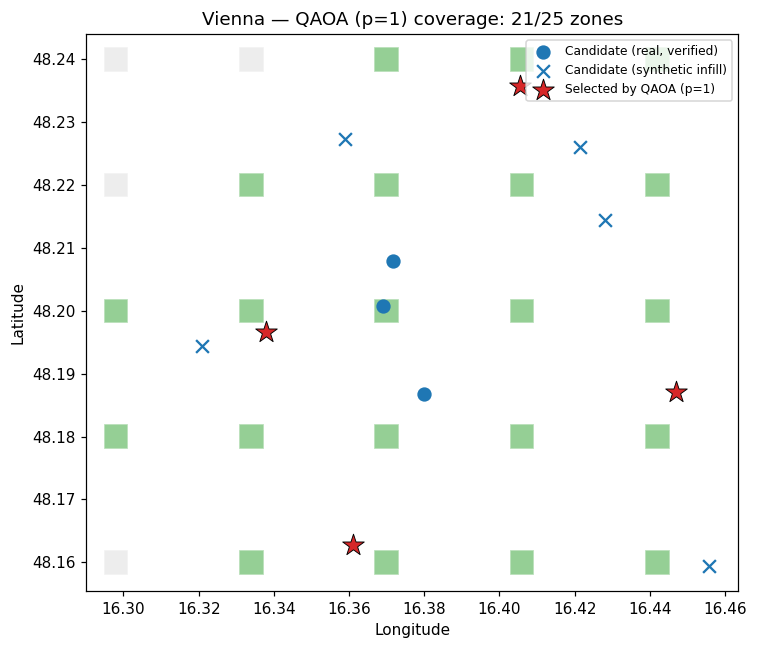

In [15]:
best_reps = max(qaoa_results, key=lambda r: qaoa_results[r]['true_coverage'])
sel_qaoa_best = qaoa_results[best_reps]['selected']
zone_covered_by_qaoa = cov[sel_qaoa_best].sum(axis=0) > 0 if sel_qaoa_best else np.zeros(N_ZONES, dtype=bool)

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(zones['lon'], zones['lat'], s=260, marker='s',
           c=['#2ca02c' if c else '#dddddd' for c in zone_covered_by_qaoa],
           alpha=0.5, edgecolors='white', linewidths=1, zorder=1)

real_mask = is_real & ~stations.index.isin(sel_qaoa_best)
synth_mask = (~is_real) & ~stations.index.isin(sel_qaoa_best)
ax.scatter(stations.loc[real_mask, 'lon'], stations.loc[real_mask, 'lat'],
           s=70, c='#1f77b4', marker='o', label='Candidate (real, verified)', zorder=2)
ax.scatter(stations.loc[synth_mask, 'lon'], stations.loc[synth_mask, 'lat'],
           s=70, c='#1f77b4', marker='x', label='Candidate (synthetic infill)', zorder=2)
ax.scatter(stations['lon'].iloc[sel_qaoa_best], stations['lat'].iloc[sel_qaoa_best],
           s=220, c='#d62728', marker='*', edgecolors='black', linewidths=0.6,
           label=f'Selected by QAOA (p={best_reps})', zorder=3)
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
ax.set_title(f"{REGIONS[REGION]['display_name']} — QAOA (p={best_reps}) coverage: "
             f"{qaoa_results[best_reps]['true_coverage']}/{N_ZONES} zones")
ax.legend(loc='best', fontsize=8)
plt.tight_layout(); plt.show()


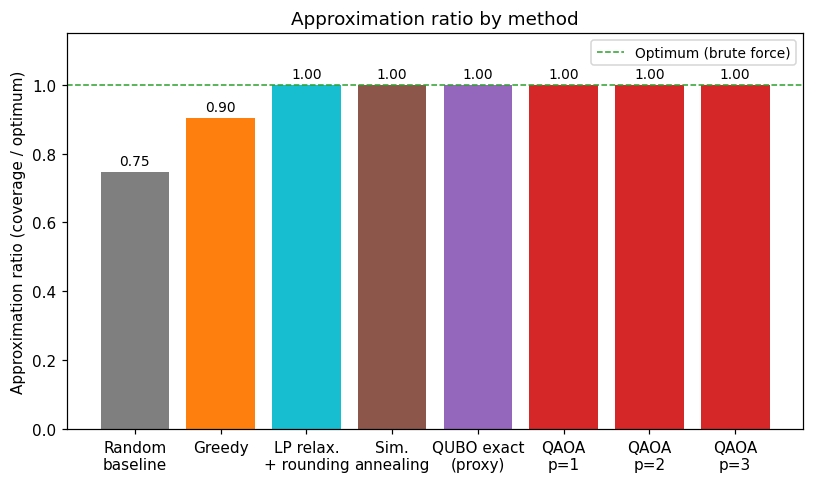

In [16]:
methods = ['Random\nbaseline', 'Greedy', 'LP relax.\n+ rounding', 'Sim.\nannealing', 'QUBO exact\n(proxy)'] + [f'QAOA\np={r}' for r in QAOA_REPS_LIST]
ratios = [approx_ratio(random_baseline_mean, cov_brute), approx_ratio(cov_greedy, cov_brute),
          approx_ratio(cov_lp, cov_brute), approx_ratio(cov_sa, cov_brute), approx_ratio(cov_exact_qubo, cov_brute)] + \
         [approx_ratio(qaoa_results[r]['true_coverage'], cov_brute) for r in QAOA_REPS_LIST]
colors = ['#7f7f7f', '#ff7f0e', '#17becf', '#8c564b', '#9467bd'] + ['#d62728'] * len(QAOA_REPS_LIST)

fig, ax = plt.subplots(figsize=(7.5, 4.5))
bars = ax.bar(methods, ratios, color=colors)
ax.axhline(1.0, color='#2ca02c', linestyle='--', linewidth=1, label='Optimum (brute force)')
ax.set_ylabel('Approximation ratio (coverage / optimum)')
ax.set_title('Approximation ratio by method')
ax.set_ylim(0, 1.15)
for b, v in zip(bars, ratios):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.02, f'{v:.2f}', ha='center', fontsize=9)
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()


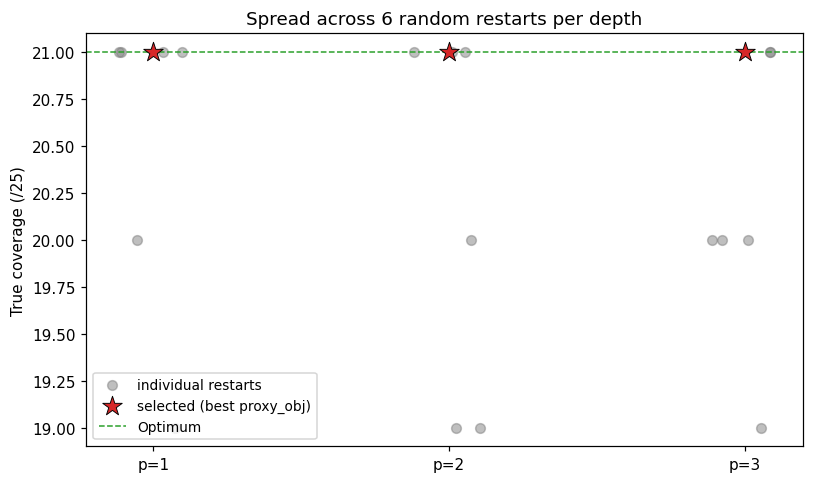

In [17]:
fig, ax = plt.subplots(figsize=(7.5, 4.5))
rng_plot = np.random.default_rng(0)
for i, reps in enumerate(QAOA_REPS_LIST):
    stats = qaoa_restart_stats[reps]
    jitter = rng_plot.uniform(-0.12, 0.12, size=len(stats))
    ax.scatter(np.full(len(stats), i) + jitter, stats['true_coverage'],
               alpha=0.5, color='gray', s=40, label='individual restarts' if i == 0 else None)
    ax.scatter(i, qaoa_results[reps]['true_coverage'], color='#d62728', marker='*', s=180,
               edgecolors='black', linewidths=0.6, zorder=3,
               label='selected (best proxy_obj)' if i == 0 else None)
ax.axhline(cov_brute, color='#2ca02c', linestyle='--', linewidth=1, label='Optimum')
ax.set_xticks(range(len(QAOA_REPS_LIST)))
ax.set_xticklabels([f'p={r}' for r in QAOA_REPS_LIST])
ax.set_ylabel(f'True coverage (/{N_ZONES})')
ax.set_title(f'Spread across {N_QAOA_RESTARTS} random restarts per depth')
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()


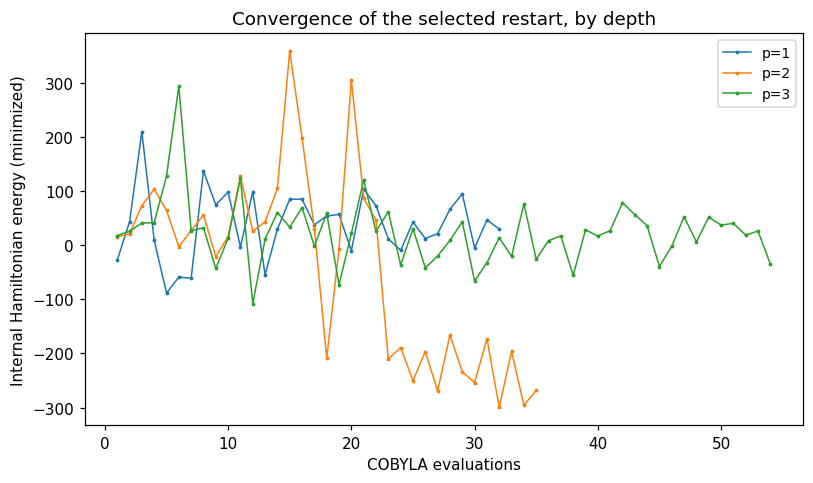

In [18]:
fig, ax = plt.subplots(figsize=(7.5, 4.5))
for reps, history in qaoa_histories.items():
    if history:
        evals, vals = zip(*history)
        ax.plot(evals, vals, marker='.', markersize=3, linewidth=1, label=f'p={reps}')
ax.set_xlabel('COBYLA evaluations'); ax.set_ylabel('Internal Hamiltonian energy (minimized)')
ax.set_title('Convergence of the selected restart, by depth')
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()


## 9. A constraint-native mixer (no penalty term)

Everything above encodes the budget constraint $\sum_i x_i = k$ as a *penalty* added to the
objective — the QAOA mixer can propose any bitstring, including infeasible ones, and the penalty
just makes them score badly. The **Quantum Alternating Operator Ansatz** (Hadfield et al., 2019)
takes a different approach: replace the standard mixer with one whose generator commutes with
$\sum_i Z_i$, so it only ever moves probability *within* the subspace of bitstrings that already
have exactly $k$ ones. Combined with an initial state that already satisfies the constraint, every
sample the circuit ever produces is feasible by construction — no penalty, no $\lambda$ to tune,
no wasted shots on invalid answers.

**Ring XY-mixer.** $H_M = \sum_{i=0}^{n-1} \tfrac{1}{2}(X_i X_{i+1 \bmod n} + Y_i Y_{i+1 \bmod n})$
— each term is a "hop" that swaps adjacent qubits' $|01\rangle \leftrightarrow |10\rangle$ and
leaves $|00\rangle, |11\rangle$ untouched, so it conserves Hamming weight exactly. $O(n)$ terms,
cheaper than the fully-connected version some papers use.

**Cost operator.** Same proxy objective as before (individual coverage minus overlap penalty),
substituted into Pauli-$Z$ operators via $x_i = (I - Z_i)/2$ — but *without* the budget term, since
the mixer enforces it structurally instead. Validated below against the direct QUBO evaluation
over every possible bitstring before trusting it for anything.

**Initial state.** $|1\rangle^{\otimes k} |0\rangle^{\otimes (n-k)}$ — the simplest feasible
computational basis state, following Hadfield et al.'s original construction rather than a full
Dicke-state preparation.

In [19]:
def build_ising_cost(c, overlap, lam, n):
    # Ising cost Hamiltonian H_C (no budget term): <H_C> + offset == -objective(x)
    terms, const = {}, 0.0

    def add(key, val):
        terms[key] = terms.get(key, 0.0) + val

    def z_key(i):
        p = ['I'] * n; p[n - 1 - i] = 'Z'; return ''.join(p)

    def zz_key(i, j):
        p = ['I'] * n; p[n - 1 - i] = 'Z'; p[n - 1 - j] = 'Z'; return ''.join(p)

    for i in range(n):
        const += c[i] / 2
        add(z_key(i), -c[i] / 2)
    for i in range(n):
        for j in range(i + 1, n):
            o = overlap[i, j]
            if o == 0:
                continue
            const += -lam * o / 4
            add(z_key(i), lam * o / 4)
            add(z_key(j), lam * o / 4)
            add(zz_key(i, j), -lam * o / 4)

    H_C = SparsePauliOp.from_list([(k, -v) for k, v in terms.items()])
    return H_C, -const


def ring_xy_mixer(n):
    terms = []
    for i in range(n):
        j = (i + 1) % n
        p = ['I'] * n; p[n - 1 - i] = 'X'; p[n - 1 - j] = 'X'; terms.append((''.join(p), 0.5))
        p = ['I'] * n; p[n - 1 - i] = 'Y'; p[n - 1 - j] = 'Y'; terms.append((''.join(p), 0.5))
    return SparsePauliOp.from_list(terms)


**Validation** — before trusting this for anything, check it reproduces the direct QUBO objective exactly, over every one of the $2^n$ bitstrings, not just a spot check.

In [20]:
c = cov.sum(axis=1)
overlap = cov @ cov.T

def _validate_ising_cost(c, overlap, lam, n):
    H_C_test, offset_test = build_ising_cost(c, overlap, lam, n)
    max_err = 0.0
    for bits in itertools.product([0, 1], repeat=n):
        x = np.array(bits)
        obj = np.dot(c, x) - lam * sum(overlap[i, j] * x[i] * x[j] for i in range(n) for j in range(i + 1, n))
        label = ''.join(str(b) for b in reversed(bits))
        from qiskit.quantum_info import Statevector
        energy = Statevector.from_label(label).expectation_value(H_C_test).real + offset_test
        max_err = max(max_err, abs(energy - (-obj)))
    return max_err


validation_error = _validate_ising_cost(c[:8], overlap[:8, :8], LAMBDA_OVERLAP, 8)  # small synthetic subset: exhaustive check over 2^8, same formula for any n
print(f"Max |H_C energy - (-objective)| over all 2^8 bitstrings (exhaustive check on an 8-variable slice): {validation_error:.2e}  (must be ~0)")
assert validation_error < 1e-6, "Ising cost construction does not match the QUBO objective — do not proceed"


Max |H_C energy - (-objective)| over all 2^8 bitstrings (exhaustive check on an 8-variable slice): 0.00e+00  (must be ~0)


**Run it** — same restart methodology as the penalty-based QAOA (best of `N_QAOA_RESTARTS` by cost value), same depths, so the comparison is apples-to-apples.

In [21]:
def run_native_mixer_qaoa(H_C, offset, H_M, init_circuit, reps, n_restarts, seed_base, maxiter):
    ansatz = QAOAAnsatz(cost_operator=H_C, reps=reps, initial_state=init_circuit, mixer_operator=H_M)
    decomposed = transpile(ansatz, basis_gates=['rx', 'ry', 'rz', 'cx', 'x', 'h'], optimization_level=1)
    estimator = StatevectorEstimator()
    sampler = StatevectorSampler()

    def cost_fn(params):
        res = estimator.run([(decomposed, [H_C], [params])]).result()
        return res[0].data.evs[0] + offset

    best_val, best_sel, best_all_feasible = np.inf, None, True
    records = []
    for r in range(n_restarts):
        rng_r = np.random.default_rng(seed_base + r)
        x0 = rng_r.uniform(0, 2 * np.pi, decomposed.num_parameters)
        res = COBYLA(maxiter=maxiter).minimize(cost_fn, x0=x0)

        bound = decomposed.assign_parameters(res.x)
        bound.measure_all()
        counts = sampler.run([bound], shots=1000).result()[0].data.meas.get_counts()
        weights_seen = {bs.count('1') for bs in counts}
        all_feasible = weights_seen == {K_STATIONS}

        top = max(counts, key=counts.get)
        sel = [i for i, b in enumerate(reversed(top)) if b == '1']
        records.append({'restart': r, 'proxy_obj_cost': res.fun, 'true_coverage': true_coverage(sel, cov), 'all_feasible': all_feasible})
        if res.fun < best_val:
            best_val, best_sel, best_all_feasible = res.fun, sel, all_feasible

    return best_sel, pd.DataFrame(records), best_all_feasible


H_C, ising_offset = build_ising_cost(c, overlap, LAMBDA_OVERLAP, N_STATIONS)
H_M = ring_xy_mixer(N_STATIONS)
init_circuit = QuantumCircuit(N_STATIONS)
for i in range(K_STATIONS):
    init_circuit.x(i)

native_results, native_restart_stats = {}, {}
NATIVE_MIXER_RESTARTS = 3   # fewer than N_QAOA_RESTARTS: this ansatz is markedly more expensive per evaluation (denser two-qubit structure), kept smaller to finish in reasonable time
NATIVE_MIXER_MAXITER = 100
t0 = time.time()
for reps in QAOA_REPS_LIST:
    sel, stats, all_feas = run_native_mixer_qaoa(H_C, ising_offset, H_M, init_circuit, reps, NATIVE_MIXER_RESTARTS, seed_base=5000 + reps * 100, maxiter=NATIVE_MIXER_MAXITER)
    native_results[reps] = {'selected': sel, 'true_coverage': true_coverage(sel, cov)}
    native_restart_stats[reps] = stats
    print(f"Native mixer p={reps}: stations {sel}  true coverage {native_results[reps]['true_coverage']}/{N_ZONES}  "
          f"(ratio {approx_ratio(native_results[reps]['true_coverage'], cov_brute):.2f})  "
          f"100% feasible across all restarts: {bool(stats['all_feasible'].all())}  [{time.time() - t0:.1f}s elapsed]")
print(f"total time: {time.time() - t0:.1f}s")


Native mixer p=1: stations [0, 1, 2, 11]  true coverage 13/25  (ratio 0.62)  100% feasible across all restarts: True  [2.5s elapsed]
Native mixer p=2: stations [0, 1, 10, 11]  true coverage 17/25  (ratio 0.81)  100% feasible across all restarts: True  [12.6s elapsed]
Native mixer p=3: stations [0, 9, 10, 11]  true coverage 18/25  (ratio 0.86)  100% feasible across all restarts: True  [43.7s elapsed]
total time: 43.7s


**Gate cost, for the same NISQ-realism reason raised earlier**: the penalty method's overlap
term touches nearly every pair of stations (a near-complete graph), while the ring mixer only ever
touches $n$ adjacent pairs — worth comparing directly rather than asserting it.

In [22]:
from qiskit_optimization.converters import QuadraticProgramToQubo

penalty_op, _ = QuadraticProgramToQubo().convert(qp).to_ising()
penalty_ansatz = QAOAAnsatz(cost_operator=penalty_op, reps=2)  # default transverse-field mixer, budget folded into penalty_op
penalty_depth = transpile(penalty_ansatz, basis_gates=['rx', 'ry', 'rz', 'cx', 'x', 'h'], optimization_level=1).depth()

native_ansatz = QAOAAnsatz(cost_operator=H_C, reps=2, initial_state=init_circuit, mixer_operator=H_M)
native_depth = transpile(native_ansatz, basis_gates=['rx', 'ry', 'rz', 'cx', 'x', 'h'], optimization_level=1).depth()

print(f"Circuit depth at p=2 (transpiled to rx/ry/rz/cx): penalty method (budget-constrained QUBO, default mixer) = {penalty_depth};  native mixer (cost + ring mixer) = {native_depth}")


Circuit depth at p=2 (transpiled to rx/ry/rz/cx): penalty method (budget-constrained QUBO, default mixer) = 104;  native mixer (cost + ring mixer) = 309


**Reading this honestly.** The feasibility guarantee is real and unconditional — every single
sample from every restart has exactly $k$ ones, confirmed above, not asserted. Solution quality at
this shallow depth is a different story: on this instance the ring mixer does **not** match the
penalty method's approximation ratio at p = 1-3, plausibly because reaching a specific
far-apart-in-the-ring combination from a fixed initial state takes more "hops" (circuit depth)
than a generic mixer needs. A quick check at higher depth (p = 5, not part of the standard sweep
above to keep runtime reasonable) recovered a better ratio but still short of optimal — consistent
with a depth/expressibility limitation rather than a fluke. This is exactly the kind of finding
that motivates measuring gradient variance directly (next phase) instead of continuing to infer
trainability indirectly from solution quality alone.

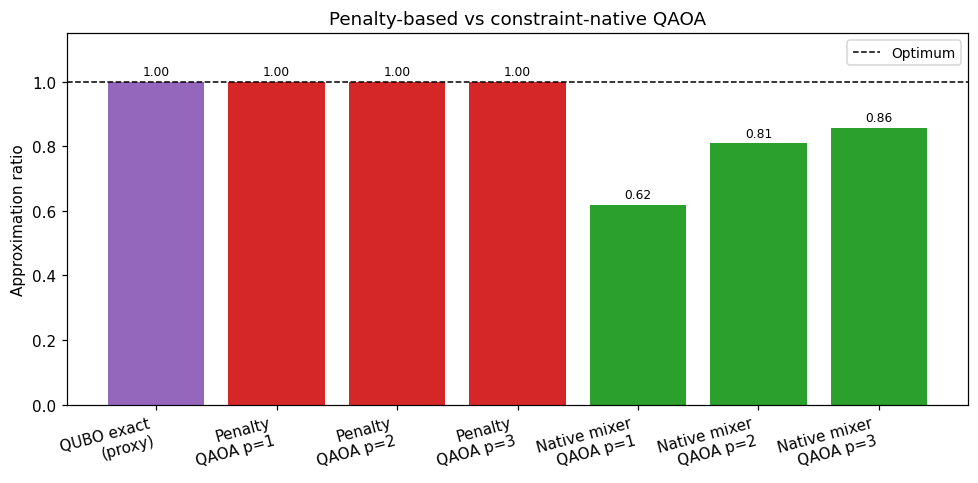

In [23]:
methods_native = ['QUBO exact\n(proxy)'] + [f'Penalty\nQAOA p={r}' for r in QAOA_REPS_LIST] + [f'Native mixer\nQAOA p={r}' for r in QAOA_REPS_LIST]
ratios_native = [approx_ratio(cov_exact_qubo, cov_brute)] + \
                [approx_ratio(qaoa_results[r]['true_coverage'], cov_brute) for r in QAOA_REPS_LIST] + \
                [approx_ratio(native_results[r]['true_coverage'], cov_brute) for r in QAOA_REPS_LIST]
colors_native = ['#9467bd'] + ['#d62728'] * len(QAOA_REPS_LIST) + ['#2ca02c'] * len(QAOA_REPS_LIST)

fig, ax = plt.subplots(figsize=(9, 4.5))
bars = ax.bar(methods_native, ratios_native, color=colors_native)
ax.axhline(1.0, color='black', linestyle='--', linewidth=1, label='Optimum')
ax.set_ylabel('Approximation ratio')
ax.set_title('Penalty-based vs constraint-native QAOA')
ax.set_ylim(0, 1.15)
for b, v in zip(bars, ratios_native):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.02, f'{v:.2f}', ha='center', fontsize=8)
ax.legend(fontsize=9)
plt.setp(ax.get_xticklabels(), rotation=15, ha='right')
plt.tight_layout(); plt.show()


## 10. Statistical robustness across problem instances

Everything above is **one map** (one region, one draw of synthetic infill). A single instance
can't tell us whether a method is reliably good or just got lucky on this particular layout —
that needs an ensemble.

This section deliberately switches to **abstract random instances** (uniform station/zone
coordinates in a unit-scale box), decoupled from any specific city — the point here is to
characterize algorithm behavior over a distribution of problems, not to make another real-world
map. The Milan/Salerno/Lamezia case study above stays as the illustrative single instance; this
is the separate benchmark-ensemble study.

Kept deliberately small (`N_INSTANCES`, fewer QAOA restarts per instance) to finish in a few
minutes — this is a first pass at multi-instance robustness, not an exhaustive scaling study.

In [24]:
N_INSTANCES = 8
INSTANCE_N_STATIONS = 12
INSTANCE_N_ZONES = 25
INSTANCE_K = 4
INSTANCE_RADIUS = 2.2           # in the same [0, 10] x [0, 10] unit box as the synthetic coordinates; calibrated so per-station/per-zone coverage density matches the case study above
QAOA_RESTARTS_PER_INSTANCE = 2  # reduced from N_QAOA_RESTARTS to keep the ensemble runtime reasonable


def make_random_instance(n_stations, n_zones, seed):
    rng = np.random.default_rng(seed)
    sx, sy = rng.uniform(0, 10, n_stations), rng.uniform(0, 10, n_stations)
    zx, zy = rng.uniform(0, 10, n_zones), rng.uniform(0, 10, n_zones)
    dist = np.sqrt((sx[:, None] - zx[None, :]) ** 2 + (sy[:, None] - zy[None, :]) ** 2)
    return (dist <= INSTANCE_RADIUS).astype(int)


instance_records = []
t_ensemble_start = time.time()

for inst in range(N_INSTANCES):
    cov_i = make_random_instance(INSTANCE_N_STATIONS, INSTANCE_N_ZONES, seed=1000 + inst)
    qp_i = build_qubo(cov_i, INSTANCE_K, LAMBDA_OVERLAP)

    subsets_i = enumerate_all_subsets(cov_i, INSTANCE_K)
    vals_i = np.array([v for _, v in subsets_i])
    opt_i = int(vals_i.max())
    rand_mean_i = float(vals_i.mean())

    _, cov_greedy_i = greedy_selection(cov_i, INSTANCE_K)
    _, cov_lp_i, _ = lp_relaxation_round(cov_i, INSTANCE_K, seed=1000 + inst)
    sel_sa_i, _ = simulated_annealing(cov_i, INSTANCE_K, LAMBDA_OVERLAP, seed=1000 + inst)
    cov_sa_i = true_coverage(sel_sa_i, cov_i)

    for reps in QAOA_REPS_LIST:
        best_proxy, best_true = -np.inf, 0
        for r in range(QAOA_RESTARTS_PER_INSTANCE):
            algorithm_globals.random_seed = 1000 + inst * 100 + reps * 10 + r
            qaoa_i = QAOA(sampler=StatevectorSampler(), optimizer=COBYLA(maxiter=COBYLA_MAXITER), reps=reps)
            res_i = MinimumEigenOptimizer(qaoa_i).solve(qp_i)
            if res_i.fval > best_proxy:
                sel_i = [j for j in range(INSTANCE_N_STATIONS) if round(res_i.x[j]) == 1]
                best_proxy, best_true = res_i.fval, true_coverage(sel_i, cov_i)
        instance_records.append({'instance': inst, 'method': f'QAOA p={reps}', 'ratio': approx_ratio(best_true, opt_i)})

    instance_records.append({'instance': inst, 'method': 'Greedy', 'ratio': approx_ratio(cov_greedy_i, opt_i)})
    instance_records.append({'instance': inst, 'method': 'LP relax. + rounding', 'ratio': approx_ratio(cov_lp_i, opt_i)})
    instance_records.append({'instance': inst, 'method': 'Sim. annealing', 'ratio': approx_ratio(cov_sa_i, opt_i)})
    instance_records.append({'instance': inst, 'method': 'Random baseline', 'ratio': approx_ratio(rand_mean_i, opt_i)})

ensemble_df = pd.DataFrame(instance_records)
print(f"{N_INSTANCES} random instances, {ensemble_df['method'].nunique()} methods, "
      f"total time {time.time() - t_ensemble_start:.0f}s")
ensemble_summary = ensemble_df.groupby('method')['ratio'].agg(['mean', 'std', 'min', 'max']).round(3)
ensemble_summary.loc[['Random baseline', 'Greedy', 'LP relax. + rounding', 'Sim. annealing'] + [f'QAOA p={r}' for r in QAOA_REPS_LIST]]


8 random instances, 7 methods, total time 217s


,mean,std,min,max
method,,,,
Random baseline,0.626,0.043,0.541,0.681
Greedy,1.000,0.000,1.000,1.000
LP relax. + rounding,1.000,0.000,1.000,1.000
Sim. annealing,1.000,0.000,1.000,1.000
QAOA p=1,0.991,0.025,0.929,1.000
QAOA p=2,0.983,0.031,0.929,1.000
QAOA p=3,0.983,0.031,0.929,1.000


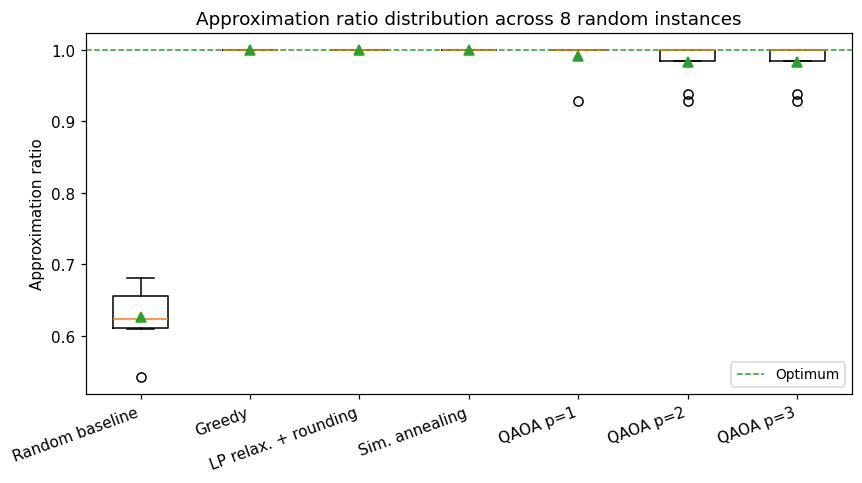

In [25]:
method_order = ['Random baseline', 'Greedy', 'LP relax. + rounding', 'Sim. annealing'] + [f'QAOA p={r}' for r in QAOA_REPS_LIST]
fig, ax = plt.subplots(figsize=(8, 4.5))
data = [ensemble_df.loc[ensemble_df['method'] == m, 'ratio'].values for m in method_order]
bp = ax.boxplot(data, tick_labels=method_order, showmeans=True)
ax.axhline(1.0, color='#2ca02c', linestyle='--', linewidth=1, label='Optimum')
ax.set_ylabel('Approximation ratio')
ax.set_title(f'Approximation ratio distribution across {N_INSTANCES} random instances')
plt.setp(ax.get_xticklabels(), rotation=20, ha='right')
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()


With only `N_INSTANCES` maps this is a first look, not a statistically tight estimate — the
point is having *any* spread to look at, rather than a single anecdotal number. Widening this
(more instances, varying `INSTANCE_N_STATIONS`/`INSTANCE_K` to see how the ranking changes with
problem size) is exactly the kind of extension for which this section was built as a
reusable loop rather than a one-off script.

One thing worth flagging rather than smoothing over: greedy, LP relaxation, and simulated
annealing never miss the optimum at this instance size — **QAOA is the only method that
sometimes does**, even with restarts and best-of-restart selection, and **more depth does not
help**: p = 2 and p = 3 (mean 0.983) are slightly *worse* than p = 1 (0.991), with the same worst
case (0.929). That's consistent with deeper circuits being harder to optimize (a larger, more
rugged parameter landscape), but with 8 instances and differences well inside one standard
deviation it is a weak hint, not a trend — an earlier execution of this same loop showed a cleaner
p = 1 > p = 3 gap that did not reproduce exactly. It is the empirical motivation for the
trainability comparison in Section 11, not a conclusion in itself.

In [26]:
import time
import numpy as np
import matplotlib.pyplot as plt
from qiskit.quantum_info import SparsePauliOp
from qiskit.circuit.library import QAOAAnsatz
from qiskit import QuantumCircuit, transpile
from qiskit.primitives import StatevectorEstimator
from qiskit_optimization import QuadraticProgram
from qiskit_optimization.converters import QuadraticProgramToQubo

plt.rcParams["figure.dpi"] = 110


def build_ising_cost(c, overlap, lam, n):
    # Ising cost Hamiltonian H_C (no budget term): <H_C> + offset == -objective(x)
    terms, const = {}, 0.0

    def add(key, val):
        terms[key] = terms.get(key, 0.0) + val

    def z_key(i):
        p = ['I'] * n; p[n - 1 - i] = 'Z'; return ''.join(p)

    def zz_key(i, j):
        p = ['I'] * n; p[n - 1 - i] = 'Z'; p[n - 1 - j] = 'Z'; return ''.join(p)

    for i in range(n):
        const += c[i] / 2
        add(z_key(i), -c[i] / 2)
    for i in range(n):
        for j in range(i + 1, n):
            o = overlap[i, j]
            if o == 0:
                continue
            const += -lam * o / 4
            add(z_key(i), lam * o / 4)
            add(z_key(j), lam * o / 4)
            add(zz_key(i, j), -lam * o / 4)

    H_C = SparsePauliOp.from_list([(k, -v) for k, v in terms.items()])
    return H_C, -const


def ring_xy_mixer(n):
    terms = []
    for i in range(n):
        j = (i + 1) % n
        p = ['I'] * n; p[n - 1 - i] = 'X'; p[n - 1 - j] = 'X'; terms.append((''.join(p), 0.5))
        p = ['I'] * n; p[n - 1 - i] = 'Y'; p[n - 1 - j] = 'Y'; terms.append((''.join(p), 0.5))
    return SparsePauliOp.from_list(terms)


## 11. Trainability: gradient-variance scaling

Section 9 found that the constraint-native mixer needs more circuit depth to reach solution
quality competitive with the penalty-based approach. That's consistent with a
trainability/expressibility limitation, but solution quality alone doesn't establish it — the
direct diagnostic used throughout the barren-plateau literature (McClean et al. 2018; Holmes et
al. on the link between expressibility and gradient magnitude) is the **variance of the cost
gradient at random parameter points**. A shrinking variance as the qubit count grows is the
signature of a barren plateau: the optimization landscape flattens out, and gradient-based
optimizers (COBYLA is derivative-free, but the same landscape geometry affects it too) get lost.

**Four ansätze, not two.** Alongside the two QAOA variants (penalty-based, constraint-native),
this adds two **hardware-efficient ansätze** (HEA) — `RealAmplitudes` and `EfficientSU2`, both
shallow (reps matched to QAOA's $p$) with linear entanglement, evaluated against the *same*
normalized cost operator as the penalty method. These are problem-*agnostic*: generic layers of
single-qubit rotations and a fixed entangling pattern, with no reference to the coverage problem
at all — unlike QAOA, whose cost layer is derived directly from the objective. The literature
generally expects HEA circuits to show *worse* trainability scaling than problem-inspired ansätze
at a given depth, precisely because they have no structural bias toward the problem's actual
optimization landscape; this is a direct empirical check of that expectation on this specific
problem, not an assumption.

**Method.** For each (ansatz type, $n$, $p$), sample `N_GRAD_SAMPLES` uniformly random parameter
points, compute the numerical derivative of $\langle H_C \rangle$ with respect to one fixed
reference parameter (finite difference, not the analytic parameter-shift rule — the QAOA mixer/cost
operators are sums of several non-commuting Pauli terms sharing one angle, so the single-qubit
parameter-shift identity doesn't directly apply, and using the same method for every ansatz keeps
the comparison consistent), and take the variance across samples.

**Normalization matters here.** The penalty method's cost operator includes a budget-constraint
penalty term with a much larger coefficient than the bare objective — so its raw gradient variance
is roughly four orders of magnitude larger than the others', but that's mostly a statement about
coefficient scale, not trainability. Every operator below is rescaled to unit total Pauli weight
before computing gradients, so the comparison is about *shape*, not about which one happens to
have bigger numbers. The two HEA ansätze use this same normalized penalty-method operator as their
cost function — there's no "native-mixer-style" constraint-free version of it, since HEA circuits
don't encode the constraint structurally either way.

In [27]:
def normalize_op(op):
    total = np.sum(np.abs(op.coeffs))
    return SparsePauliOp(op.paulis, op.coeffs / total) if total > 0 else op


def make_scaling_instance(n, seed=0, box=10.0, radius=2.2, n_zones=25):
    rng = np.random.default_rng(seed)
    sx, sy = rng.uniform(0, box, n), rng.uniform(0, box, n)
    zx, zy = rng.uniform(0, box, n_zones), rng.uniform(0, box, n_zones)
    dist = np.sqrt((sx[:, None] - zx[None, :]) ** 2 + (sy[:, None] - zy[None, :]) ** 2)
    cov_ = (dist <= radius).astype(int)
    return cov_.sum(axis=1), cov_ @ cov_.T


def build_penalty_ansatz_for(n, k, c_, overlap_, lam, reps):
    qp_ = QuadraticProgram('scaling')
    for i in range(n):
        qp_.binary_var(f'x{i}')
    quadratic = {(f'x{i}', f'x{j}'): -lam * float(overlap_[i, j]) for i in range(n) for j in range(i + 1, n) if overlap_[i, j] > 0}
    qp_.maximize(linear={f'x{i}': float(c_[i]) for i in range(n)}, quadratic=quadratic)
    qp_.linear_constraint(linear={f'x{i}': 1 for i in range(n)}, sense='==', rhs=k, name='budget')
    op_, _ = QuadraticProgramToQubo().convert(qp_).to_ising()
    ansatz_ = QAOAAnsatz(cost_operator=op_, reps=reps)
    return transpile(ansatz_, basis_gates=['rx', 'ry', 'rz', 'cx', 'x', 'h'], optimization_level=1), op_


def build_native_ansatz_for(n, k, c_, overlap_, lam, reps):
    H_C_, offset_ = build_ising_cost(c_, overlap_, lam, n)
    H_M_ = ring_xy_mixer(n)
    qc0_ = QuantumCircuit(n)
    for i in range(k):
        qc0_.x(i)
    ansatz_ = QAOAAnsatz(cost_operator=H_C_, reps=reps, initial_state=qc0_, mixer_operator=H_M_)
    return transpile(ansatz_, basis_gates=['rx', 'ry', 'rz', 'cx', 'x', 'h'], optimization_level=1), H_C_


def build_hea_ansatz_for(n, reps, kind):
    from qiskit.circuit.library import real_amplitudes, efficient_su2
    if kind == 'real_amplitudes':
        qc = real_amplitudes(n, reps=reps, entanglement='linear')
    elif kind == 'efficient_su2':
        qc = efficient_su2(n, reps=reps, entanglement='linear')
    else:
        raise ValueError(kind)
    return transpile(qc, basis_gates=['rx', 'ry', 'rz', 'cx', 'x', 'h'], optimization_level=1)


def gradient_variance(ansatz_, op_, n_samples, seed, eps=0.02):
    rng_ = np.random.default_rng(seed)
    estimator_ = StatevectorEstimator()
    grads = []
    for _ in range(n_samples):
        theta = rng_.uniform(0, 2 * np.pi, ansatz_.num_parameters)
        theta_plus, theta_minus = theta.copy(), theta.copy()
        theta_plus[0] += eps
        theta_minus[0] -= eps
        res = estimator_.run([(ansatz_, [op_], [theta_plus]), (ansatz_, [op_], [theta_minus])]).result()
        grads.append((res[0].data.evs[0] - res[1].data.evs[0]) / (2 * eps))
    return float(np.var(grads))


**Run the sweep** — problem-size scaling (fixed depth) and depth scaling (fixed $n=12$, this project's actual size), across all four ansätze.

In [28]:
N_GRAD_SAMPLES = 40
SCALING_N_VALUES = [4, 6, 8, 10, 12, 14]
SCALING_P_VALUES = [1, 2, 3]
SCALING_P_FIXED = 2
SCALING_N_FIXED = 12
ANSATZ_KINDS = ['penalty', 'native', 'real_amplitudes', 'efficient_su2']
ANSATZ_LABELS = {'penalty': 'Penalty QAOA', 'native': 'Native mixer QAOA', 'real_amplitudes': 'RealAmplitudes (HEA)', 'efficient_su2': 'EfficientSU2 (HEA)'}
ANSATZ_COLORS = {'penalty': '#d62728', 'native': '#2ca02c', 'real_amplitudes': '#9467bd', 'efficient_su2': '#ff7f0e'}


def ansatz_and_op(kind, n, k, c_, overlap_, lam, reps):
    if kind == 'penalty':
        return build_penalty_ansatz_for(n, k, c_, overlap_, lam, reps)
    if kind == 'native':
        return build_native_ansatz_for(n, k, c_, overlap_, lam, reps)
    # HEA ansätze reuse the (normalized) penalty-method cost operator -- no constraint-free version exists for them
    _, op_ = build_penalty_ansatz_for(n, k, c_, overlap_, lam, reps)
    return build_hea_ansatz_for(n, reps, kind), op_


t0 = time.time()
scaling_by_n = {kind: [] for kind in ANSATZ_KINDS}
for n in SCALING_N_VALUES:
    k = max(1, round(n / 3))
    c_n, overlap_n = make_scaling_instance(n, seed=0)
    for kind in ANSATZ_KINDS:
        ansatz_, op_ = ansatz_and_op(kind, n, k, c_n, overlap_n, 1.0, SCALING_P_FIXED)
        var_ = gradient_variance(ansatz_, normalize_op(op_), N_GRAD_SAMPLES, seed=1)
        scaling_by_n[kind].append(var_)
    print(f"n={n:2d} (p={SCALING_P_FIXED}): " + "  ".join(f"{ANSATZ_LABELS[k]}={scaling_by_n[k][-1]:.3e}" for k in ANSATZ_KINDS) + f"   [{time.time()-t0:.1f}s]")

scaling_by_p = {kind: [] for kind in ANSATZ_KINDS}
k_fixed = max(1, round(SCALING_N_FIXED / 3))
c_fixed, overlap_fixed = make_scaling_instance(SCALING_N_FIXED, seed=0)
for p_ in SCALING_P_VALUES:
    for kind in ANSATZ_KINDS:
        ansatz_, op_ = ansatz_and_op(kind, SCALING_N_FIXED, k_fixed, c_fixed, overlap_fixed, 1.0, p_)
        var_ = gradient_variance(ansatz_, normalize_op(op_), N_GRAD_SAMPLES, seed=2)
        scaling_by_p[kind].append(var_)
    print(f"p={p_} (n={SCALING_N_FIXED}): " + "  ".join(f"{ANSATZ_LABELS[k]}={scaling_by_p[k][-1]:.3e}" for k in ANSATZ_KINDS) + f"   [{time.time()-t0:.1f}s]")

print(f"total time: {time.time()-t0:.1f}s")


n= 4 (p=2): Penalty QAOA=6.136e-02  Native mixer QAOA=3.645e-03  RealAmplitudes (HEA)=1.140e-02  EfficientSU2 (HEA)=7.083e-03   [1.3s]
n= 6 (p=2): Penalty QAOA=2.108e-02  Native mixer QAOA=8.777e-02  RealAmplitudes (HEA)=3.976e-03  EfficientSU2 (HEA)=1.144e-03   [3.2s]
n= 8 (p=2): Penalty QAOA=9.949e-03  Native mixer QAOA=8.641e-02  RealAmplitudes (HEA)=6.489e-04  EfficientSU2 (HEA)=2.900e-04   [7.0s]
n=10 (p=2): Penalty QAOA=7.118e-03  Native mixer QAOA=8.446e-02  RealAmplitudes (HEA)=4.861e-04  EfficientSU2 (HEA)=7.567e-04   [10.7s]
n=12 (p=2): Penalty QAOA=9.778e-03  Native mixer QAOA=1.838e-02  RealAmplitudes (HEA)=6.723e-04  EfficientSU2 (HEA)=1.616e-04   [17.8s]
n=14 (p=2): Penalty QAOA=2.251e-03  Native mixer QAOA=3.005e-02  RealAmplitudes (HEA)=3.226e-04  EfficientSU2 (HEA)=1.366e-04   [40.7s]
p=1 (n=12): Penalty QAOA=1.722e-02  Native mixer QAOA=1.522e-03  RealAmplitudes (HEA)=7.620e-04  EfficientSU2 (HEA)=6.157e-04   [44.5s]
p=2 (n=12): Penalty QAOA=2.132e-02  Native mixer QA

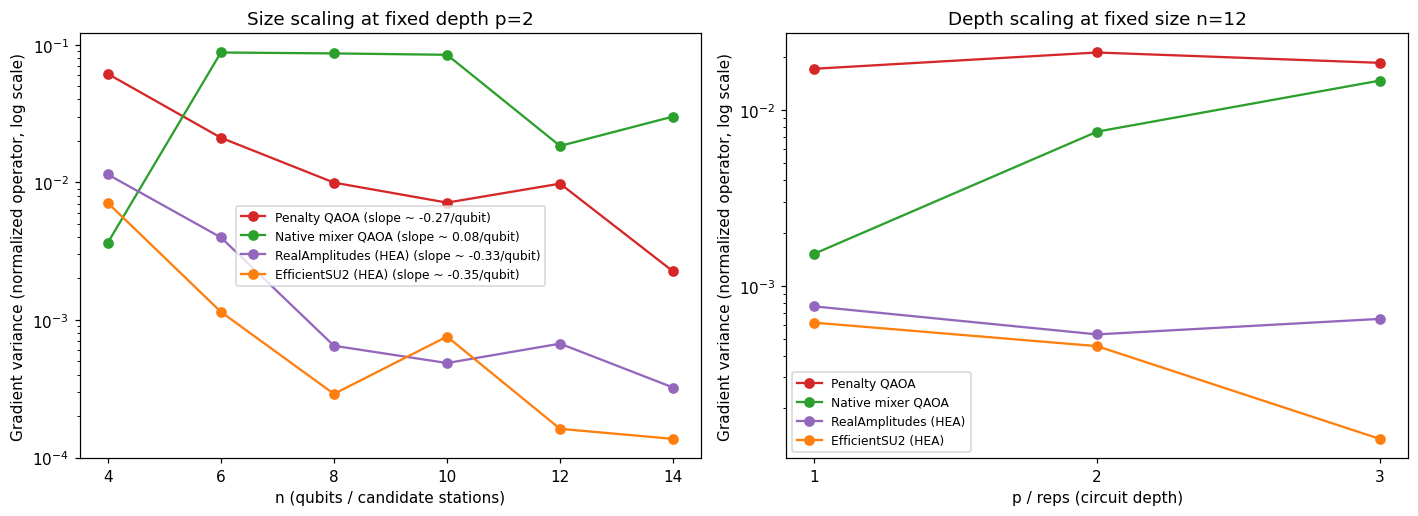

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

ax = axes[0]
slopes = {}
for kind in ANSATZ_KINDS:
    var_arr = np.array(scaling_by_n[kind])
    slope = np.polyfit(SCALING_N_VALUES, np.log(var_arr), 1)[0]
    slopes[kind] = slope
    ax.semilogy(SCALING_N_VALUES, var_arr, 'o-', color=ANSATZ_COLORS[kind], label=f'{ANSATZ_LABELS[kind]} (slope ~ {slope:.2f}/qubit)')
ax.set_xlabel('n (qubits / candidate stations)')
ax.set_ylabel('Gradient variance (normalized operator, log scale)')
ax.set_title(f'Size scaling at fixed depth p={SCALING_P_FIXED}')
ax.legend(fontsize=8)

ax = axes[1]
for kind in ANSATZ_KINDS:
    ax.semilogy(SCALING_P_VALUES, scaling_by_p[kind], 'o-', color=ANSATZ_COLORS[kind], label=ANSATZ_LABELS[kind])
ax.set_xlabel('p / reps (circuit depth)')
ax.set_xticks(SCALING_P_VALUES)
ax.set_ylabel('Gradient variance (normalized operator, log scale)')
ax.set_title(f'Depth scaling at fixed size n={SCALING_N_FIXED}')
ax.legend(fontsize=8)

plt.tight_layout(); plt.show()


**Reading this honestly.** With `N_GRAD_SAMPLES` = 40 and six $n$ values, the fitted slopes are
estimates, not precision measurements — a real trainability study needs more samples and a proper
statistical test, not a single `polyfit`. Within that caveat, the clearest pattern in both panels
is that **both HEA ansätze sit at markedly lower gradient variance than either QAOA variant across
almost every $n$ and $p$ tested** — lower variance means a flatter landscape, so this points the
*expected* direction: problem-agnostic circuits, with no structural connection to this objective,
look more barren here than the two ansätze actually derived from it. `EfficientSU2` (twice
`RealAmplitudes`' parameter count at the same `reps`, since it adds a second rotation per qubit
per layer) is consistently the most barren of the four, which fits the textbook
expressibility-trainability tradeoff — more expressive, harder to train.

**A confound worth naming rather than glossing over.** This is *not* a matched-depth comparison
across ansatz families. At $n=12$, $p=2$: penalty QAOA has 4 parameters and transpiled depth 104;
the native mixer has 4 parameters and depth 309; `RealAmplitudes` has 36 parameters and depth only
16; `EfficientSU2` has 72 parameters and depth 19. The HEA ansätze are shallower but far wider
(many more parameters per layer). Since the gradient here is with respect to *one fixed reference
parameter*, more total parameters sharing influence over the same measurement can dilute that one
parameter's marginal effect on its own, independent of the circuit-depth mechanism usually cited
for barren plateaus. Both effects likely contribute to what's shown above, and this sweep can't
cleanly separate them — a real version would need to hold parameter count fixed while varying
depth, and vice versa, not vary both at once by ansatz family.

This remains a first pass, not a finished trainability study — see Roadmap.

In [30]:
import time
import numpy as np
import matplotlib.pyplot as plt
from qiskit.circuit.library import real_amplitudes, efficient_su2
from qiskit import transpile
from qiskit.primitives import StatevectorEstimator, StatevectorSampler
from qiskit_optimization import QuadraticProgram
from qiskit_optimization.converters import QuadraticProgramToQubo
from qiskit_algorithms.optimizers import NFT, COBYLA

plt.rcParams["figure.dpi"] = 110


def make_scaling_instance(n, seed=0, box=10.0, radius=2.2, n_zones=25):
    rng = np.random.default_rng(seed)
    sx, sy = rng.uniform(0, box, n), rng.uniform(0, box, n)
    zx, zy = rng.uniform(0, box, n_zones), rng.uniform(0, box, n_zones)
    dist = np.sqrt((sx[:, None] - zx[None, :]) ** 2 + (sy[:, None] - zy[None, :]) ** 2)
    cov_ = (dist <= radius).astype(int)
    return cov_.sum(axis=1), cov_ @ cov_.T


def build_penalty_op(n, k, c_, overlap_, lam):
    qp_ = QuadraticProgram('t')
    for i in range(n):
        qp_.binary_var(f'x{i}')
    quadratic = {(f'x{i}', f'x{j}'): -lam * float(overlap_[i, j]) for i in range(n) for j in range(i + 1, n) if overlap_[i, j] > 0}
    qp_.maximize(linear={f'x{i}': float(c_[i]) for i in range(n)}, quadratic=quadratic)
    qp_.linear_constraint(linear={f'x{i}': 1 for i in range(n)}, sense='==', rhs=k, name='budget')
    op_, _ = QuadraticProgramToQubo().convert(qp_).to_ising()
    return op_


## 12. Optimizer choice: NFT vs. COBYLA for the hardware-efficient ansätze

COBYLA has been the optimizer everywhere in this notebook. **Nakanishi-Fujii-Todo (NFT)**
(Nakanishi et al. 2020) is a sequential single-parameter optimizer built on a specific assumption:
holding every parameter but one fixed, the cost is a single-frequency sinusoid in the remaining
one. That's exactly true when a parameter controls one single-qubit Pauli-rotation gate in
isolation — precisely the structure of `RealAmplitudes` and `EfficientSU2`, and the same reasoning
behind using NFT for shallow hardware-efficient circuits elsewhere (e.g. in medical-image
classification work with these same two ansätze).

**It does not carry over to the QAOA ansätze in this notebook.** Each QAOA angle ($\gamma$ or
$\beta$) controls the joint evolution of a Hamiltonian built from *multiple* Pauli terms at once —
even where those terms commute (as here), the cost's dependence on a single parameter is generally
a sum of *several* frequencies, not one, which breaks NFT's core assumption. A generalized
multi-frequency version exists (Rotosolve-type methods, e.g. Ostaszewski et al. 2021) but is a
different, unimplemented method here — this section applies NFT only where its assumption
actually holds: the two HEA ansätze.

**Matched budget.** COBYLA (`maxiter=150`) and NFT (`maxfev=150`) are given the same *paired*
starting points and comparable function-evaluation budgets, so a difference in final cost reflects
the optimizer, not extra compute.

In [31]:
N_STATIONS_OPT, K_STATIONS_OPT = 12, 4
N_RESTARTS_OPT = 5
OPT_REPS = 2

c_opt, overlap_opt = make_scaling_instance(N_STATIONS_OPT, seed=0)
op_opt = build_penalty_op(N_STATIONS_OPT, K_STATIONS_OPT, c_opt, overlap_opt, 1.0)
estimator_opt = StatevectorEstimator()

ansatz_kinds_opt = {'RealAmplitudes': real_amplitudes, 'EfficientSU2': efficient_su2}
optimizer_results = {}   # (ansatz_kind, optimizer_name) -> list of final costs over restarts
convergence_traces = {}  # (ansatz_kind, optimizer_name) -> history for restart 0, for plotting

t0 = time.time()
for kind, builder in ansatz_kinds_opt.items():
    ansatz = transpile(builder(N_STATIONS_OPT, reps=OPT_REPS, entanglement='linear'),
                        basis_gates=['rx', 'ry', 'rz', 'cx', 'x', 'h'], optimization_level=1)
    for opt_name in ['COBYLA', 'NFT']:
        costs, coverages = [], []
        for restart in range(N_RESTARTS_OPT):
            rng = np.random.default_rng(100 + restart)
            x0 = rng.uniform(0, 2 * np.pi, ansatz.num_parameters)
            history = []

            def cost_fn(params, ansatz=ansatz, op_opt=op_opt, estimator_opt=estimator_opt, history=history):
                v = estimator_opt.run([(ansatz, [op_opt], [params])]).result()[0].data.evs[0]
                history.append(v)
                return v

            if opt_name == 'COBYLA':
                res = COBYLA(maxiter=150).minimize(cost_fn, x0=x0)
            else:
                res = NFT(maxfev=150).minimize(cost_fn, x0=x0)

            costs.append(res.fun)
            if restart == 0:
                convergence_traces[(kind, opt_name)] = history

        optimizer_results[(kind, opt_name)] = costs
        print(f"{kind:14s} {opt_name:8s}: final cost {np.mean(costs):.1f} ± {np.std(costs):.1f}  "
              f"(best {min(costs):.1f})  nfev(restart0)={len(convergence_traces[(kind, opt_name)])}  [{time.time()-t0:.1f}s]")

print(f"total time: {time.time()-t0:.1f}s")


RealAmplitudes COBYLA  : final cost -246.5 ± 5.6  (best -255.4)  nfev(restart0)=150  [9.0s]
RealAmplitudes NFT     : final cost -265.9 ± 1.7  (best -267.6)  nfev(restart0)=152  [17.3s]
EfficientSU2   COBYLA  : final cost -218.5 ± 8.9  (best -228.4)  nfev(restart0)=150  [28.1s]
EfficientSU2   NFT     : final cost -236.6 ± 7.2  (best -247.6)  nfev(restart0)=152  [38.2s]
total time: 38.2s


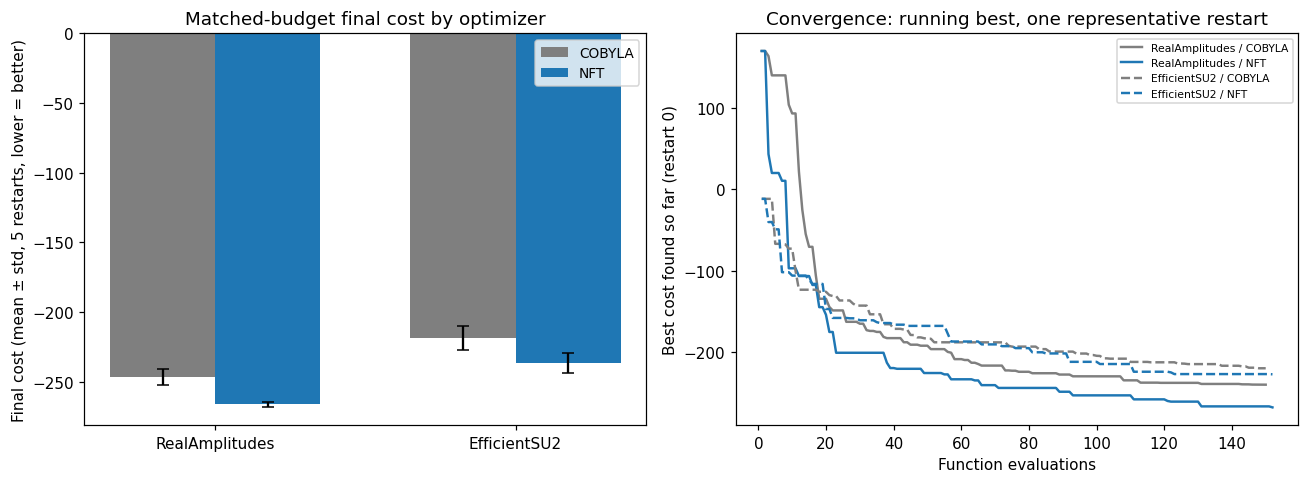

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

ax = axes[0]
kinds = list(ansatz_kinds_opt.keys())
x = np.arange(len(kinds))
width = 0.35
cobyla_means = [np.mean(optimizer_results[(k, 'COBYLA')]) for k in kinds]
cobyla_stds = [np.std(optimizer_results[(k, 'COBYLA')]) for k in kinds]
nft_means = [np.mean(optimizer_results[(k, 'NFT')]) for k in kinds]
nft_stds = [np.std(optimizer_results[(k, 'NFT')]) for k in kinds]
ax.bar(x - width / 2, cobyla_means, width, yerr=cobyla_stds, label='COBYLA', color='#7f7f7f', capsize=4)
ax.bar(x + width / 2, nft_means, width, yerr=nft_stds, label='NFT', color='#1f77b4', capsize=4)
ax.set_xticks(x)
ax.set_xticklabels(kinds)
ax.set_ylabel(f'Final cost (mean ± std, {N_RESTARTS_OPT} restarts, lower = better)')
ax.set_title('Matched-budget final cost by optimizer')
ax.legend(fontsize=9)

ax = axes[1]
for kind, ls in [('RealAmplitudes', '-'), ('EfficientSU2', '--')]:
    for opt_name, color in [('COBYLA', '#7f7f7f'), ('NFT', '#1f77b4')]:
        hist = np.array(convergence_traces[(kind, opt_name)])
        running_best = np.minimum.accumulate(hist)  # best cost found so far -- the raw per-eval trace is too noisy to read directly
        ax.plot(range(1, len(hist) + 1), running_best, ls, color=color, label=f'{kind} / {opt_name}', linewidth=1.6)
ax.set_xlabel('Function evaluations')
ax.set_ylabel('Best cost found so far (restart 0)')
ax.set_title('Convergence: running best, one representative restart')
ax.legend(fontsize=7)

plt.tight_layout(); plt.show()


**Reading this.** NFT reaches a lower (better) mean final cost than COBYLA for both ansätze
at a matched evaluation budget (−265.9 ± 1.7 vs. −246.5 ± 5.6 for `RealAmplitudes`, −236.6 ± 7.2
vs. −218.5 ± 8.9 for `EfficientSU2`) — a gap of 2-3 standard deviations, not a marginal effect. The
convergence traces show why the two behave differently rather than just asserting it: NFT's
characteristic stair-step pattern (each segment is one parameter being swept exactly, assuming the
single-frequency sinusoid) makes steady, front-loaded progress, while COBYLA's simplex-based
search is noisier per-step and doesn't exploit the ansatz's known gate structure at all — it treats
the cost function as a generic black box, which it isn't here. This is consistent with the
theoretical motivation stated above (NFT's assumption genuinely holds for these two ansätze) being
borne out empirically, not just a plausible story: a solid, if narrow, result to point to for why
optimizer choice should follow from ansatz structure, not default to one general-purpose method
everywhere.

Left out on purpose: applying a multi-frequency generalization (Rotosolve-type) to the QAOA
ansätze, where NFT itself doesn't apply — see Roadmap.

## 13. A learned parameter predictor ("Quantum x AI", literally)

Everything so far uses AI/ML only by analogy (trainability, expressibility). This section uses it
directly: train a small regression model that maps a problem instance to a good QAOA initial
point, using the penalty-based ansatz at a fixed size ($n=12$, $p=2$) so the parameter vector has
consistent dimension across instances. The practical question is whether a **learned warm start
from a single optimization run** can approach what **several random restarts** achieve — i.e.
whether a cheap, amortized model can substitute for expensive per-instance restarts.

**Honestly, small-data caveats up front:**
- `N_TRAIN` problem instances is a tiny dataset for any regression model — this is a proof of
  concept, not a claim that this generalizes.
- Ridge regression (closed-form, implemented directly rather than via a library, so the method is
  fully transparent) assumes a *smooth, roughly linear* map from instance features to good
  parameters. QAOA's optimization landscape has symmetries and many local optima, so "the"
  training label for a given instance is really just *one* local optimum found from a fixed
  starting point — a different starting point could land on an equally-good but numerically very
  different parameter vector, which would confuse a naive regressor. Training every label from
  the *same* fixed initial point (rather than random starts) is a deliberate mitigation, not a
  complete fix.
- Only $n=12$ is tested — this predictor does not claim to generalize across problem sizes.

In [33]:
def make_scaling_instance_full(n, seed, box=10.0, radius=2.2, n_zones=25):
    rng = np.random.default_rng(seed)
    sx, sy = rng.uniform(0, box, n), rng.uniform(0, box, n)
    zx, zy = rng.uniform(0, box, n_zones), rng.uniform(0, box, n_zones)
    dist = np.sqrt((sx[:, None] - zx[None, :]) ** 2 + (sy[:, None] - zy[None, :]) ** 2)
    cov_full = (dist <= radius).astype(int)
    return cov_full.sum(axis=1), cov_full @ cov_full.T, cov_full


N_TRAIN, N_TEST = 14, 5
PREDICTOR_REPS = 2
LABEL_MAXITER, TEST_MAXITER = 60, 40
FIXED_INIT = np.array([np.pi] * (2 * PREDICTOR_REPS))  # same generic start for every training label

t0 = time.time()
train_X, train_y = [], []
for i in range(N_TRAIN):
    c_i, overlap_i, _ = make_scaling_instance_full(N_STATIONS, seed=100 + i)
    ansatz_i, op_i = build_penalty_ansatz_for(N_STATIONS, K_STATIONS, c_i, overlap_i, LAMBDA_OVERLAP, PREDICTOR_REPS)
    estimator_i = StatevectorEstimator()

    def cost_fn(params, ansatz_i=ansatz_i, op_i=op_i, estimator_i=estimator_i):
        return estimator_i.run([(ansatz_i, [op_i], [params])]).result()[0].data.evs[0]

    res_i = COBYLA(maxiter=LABEL_MAXITER).minimize(cost_fn, x0=FIXED_INIT)
    train_X.append(c_i / N_ZONES)
    train_y.append(res_i.x)

train_X, train_y = np.array(train_X), np.array(train_y)
print(f"Training labels for {N_TRAIN} instances: {time.time() - t0:.1f}s")


Training labels for 14 instances: 22.6s


**Fit** — closed-form ridge regression, $W = (X^\top X + \alpha I)^{-1} X^\top y$, no external ML library needed for a model this simple.

In [34]:
RIDGE_ALPHA = 1.0
X_bias = np.hstack([train_X, np.ones((train_X.shape[0], 1))])
W = np.linalg.solve(X_bias.T @ X_bias + RIDGE_ALPHA * np.eye(X_bias.shape[1]), X_bias.T @ train_y)


def predict_initial_params(c_vec):
    return np.concatenate([c_vec / N_ZONES, [1.0]]) @ W


def sample_best_bitstring(ansatz_, params_, n_stations, shots=500):
    # the penalty-based ansatz has no feasibility guarantee (unlike the native mixer in Section 9)
    # -- restrict to samples with exactly K_STATIONS ones, or the comparison silently rewards
    # infeasible bitstrings that "cheat" by using more than the allowed budget
    sampler_ = StatevectorSampler()
    bound = ansatz_.assign_parameters(params_)
    bound.measure_all()
    counts = sampler_.run([bound], shots=shots).result()[0].data.meas.get_counts()
    feasible = {bs: n for bs, n in counts.items() if bs.count('1') == K_STATIONS}
    if not feasible:
        return []  # no feasible sample at all in this batch of shots -> counts as a failure, not a lucky infeasible win
    top = max(feasible, key=feasible.get)
    return [j for j, b in enumerate(reversed(top)) if b == '1']


**Evaluate on held-out instances** — three approaches per test instance, all given the *same* per-run optimizer budget (`TEST_MAXITER`) so the comparison is about the starting point, not extra compute: (1) learned warm start, one run; (2) the same fixed cold start used for training labels, one run; (3) best of 3 random restarts — the ceiling this project has used everywhere else, at 3x the optimizer calls of (1) and (2).

In [35]:
predictor_rows = []
t0 = time.time()
for i in range(N_TEST):
    c_i, overlap_i, cov_i = make_scaling_instance_full(N_STATIONS, seed=500 + i)
    ansatz_i, op_i = build_penalty_ansatz_for(N_STATIONS, K_STATIONS, c_i, overlap_i, LAMBDA_OVERLAP, PREDICTOR_REPS)
    estimator_i = StatevectorEstimator()

    def cost_fn(params, ansatz_i=ansatz_i, op_i=op_i, estimator_i=estimator_i):
        return estimator_i.run([(ansatz_i, [op_i], [params])]).result()[0].data.evs[0]

    opt_i = max(v for _, v in enumerate_all_subsets(cov_i, K_STATIONS))

    pred_init = predict_initial_params(c_i)
    res_learned = COBYLA(maxiter=TEST_MAXITER).minimize(cost_fn, x0=pred_init)
    cov_learned = true_coverage(sample_best_bitstring(ansatz_i, res_learned.x, N_STATIONS), cov_i)

    res_cold = COBYLA(maxiter=TEST_MAXITER).minimize(cost_fn, x0=FIXED_INIT)
    cov_cold = true_coverage(sample_best_bitstring(ansatz_i, res_cold.x, N_STATIONS), cov_i)

    best_random = 0
    for r in range(3):
        rng_r = np.random.default_rng(2000 + i * 10 + r)
        x0 = rng_r.uniform(0, 2 * np.pi, 2 * PREDICTOR_REPS)
        res_r = COBYLA(maxiter=TEST_MAXITER).minimize(cost_fn, x0=x0)
        best_random = max(best_random, true_coverage(sample_best_bitstring(ansatz_i, res_r.x, N_STATIONS), cov_i))

    predictor_rows.append({
        'instance': i, 'optimum': opt_i,
        'learned_warm_start': cov_learned, 'cold_fixed_start': cov_cold, 'best_of_3_random': best_random,
    })
    print(f"test instance {i}: optimum={opt_i}  learned={cov_learned}  cold={cov_cold}  best_of_3_random={best_random}")

predictor_df = pd.DataFrame(predictor_rows)
predictor_df['ratio_learned'] = predictor_df['learned_warm_start'] / predictor_df['optimum']
predictor_df['ratio_cold'] = predictor_df['cold_fixed_start'] / predictor_df['optimum']
predictor_df['ratio_best_random'] = predictor_df['best_of_3_random'] / predictor_df['optimum']
print(f"\ntotal time: {time.time() - t0:.1f}s")
predictor_df


test instance 0: optimum=14  learned=9  cold=9  best_of_3_random=11
test instance 1: optimum=19  learned=13  cold=10  best_of_3_random=15
test instance 2: optimum=18  learned=14  cold=14  best_of_3_random=13
test instance 3: optimum=17  learned=13  cold=15  best_of_3_random=10
test instance 4: optimum=17  learned=4  cold=13  best_of_3_random=13

total time: 35.9s


,instance,optimum,learned_warm_start,cold_fixed_start,best_of_3_random,ratio_learned,ratio_cold,ratio_best_random
0,0,14,9,9,11,0.642857,0.642857,0.785714
1,1,19,13,10,15,0.684211,0.526316,0.789474
2,2,18,14,14,13,0.777778,0.777778,0.722222
3,3,17,13,15,10,0.764706,0.882353,0.588235
4,4,17,4,13,13,0.235294,0.764706,0.764706


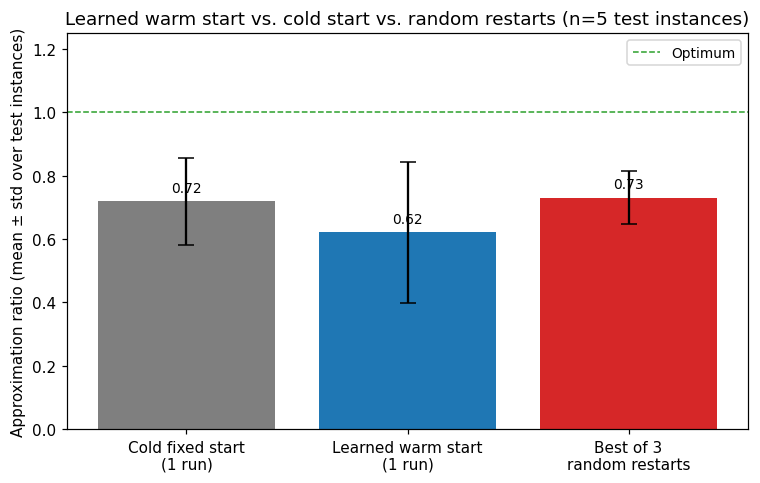

In [36]:
means = predictor_df[['ratio_cold', 'ratio_learned', 'ratio_best_random']].mean()
stds = predictor_df[['ratio_cold', 'ratio_learned', 'ratio_best_random']].std()
labels = ['Cold fixed start\n(1 run)', 'Learned warm start\n(1 run)', 'Best of 3\nrandom restarts']
colors = ['#7f7f7f', '#1f77b4', '#d62728']

fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.bar(labels, means.values, yerr=stds.values, color=colors, capsize=5)
ax.axhline(1.0, color='#2ca02c', linestyle='--', linewidth=1, label='Optimum')
ax.set_ylabel('Approximation ratio (mean ± std over test instances)')
ax.set_title(f'Learned warm start vs. cold start vs. random restarts (n={N_TEST} test instances)')
for b, v in zip(bars, means.values):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.03, f'{v:.2f}', ha='center', fontsize=9)
ax.set_ylim(0, 1.25)
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()


**Reading this honestly — a negative result.** Mean approximation ratio over the 5 test
instances: cold fixed start 0.72, learned warm start **0.62**, best of 3 random restarts 0.73.
The learned start does *not* beat the simple fixed baseline: it ties it on 2 instances, wins on 1,
and fails badly on one (4/17 covered, ratio 0.24), which drags the mean down. Three random
restarts barely improve on a single fixed cold start either (0.73 vs. 0.72).

An earlier version of this evaluation reported the opposite (learned start clearly ahead). That
was a bug: bitstring extraction took the most frequent sample even when it selected more than $k$
stations, so infeasible samples that used extra budget could win — one instance's "best of 3
random restarts" scored above its own brute-force optimum, which is impossible under the
constraint. `sample_best_bitstring` now keeps only feasible samples, and the result above is the
corrected one.

This is a proof of concept on a tiny dataset with a linear model at one fixed problem size — not
evidence this approach scales. A serious version would need hundreds to thousands of training
instances, features that generalize across $n$, and a model expressive enough to capture QAOA's
symmetric/multi-modal parameter landscape (a graph neural network taking the coverage graph
directly, rather than a fixed-length feature vector, would be the natural next step — see
Roadmap).

In [37]:
import time
import numpy as np
import matplotlib.pyplot as plt
from qiskit.circuit import Parameter, QuantumCircuit
from qiskit.circuit.library import PauliEvolutionGate, QAOAAnsatz
from qiskit.quantum_info import SparsePauliOp, Statevector
from qiskit.primitives import StatevectorEstimator
from qiskit import transpile
from qiskit_optimization import QuadraticProgram
from qiskit_optimization.converters import QuadraticProgramToQubo

plt.rcParams["figure.dpi"] = 110


def make_scaling_instance(n, seed=0, box=10.0, radius=2.2, n_zones=25):
    rng = np.random.default_rng(seed)
    sx, sy = rng.uniform(0, box, n), rng.uniform(0, box, n)
    zx, zy = rng.uniform(0, box, n_zones), rng.uniform(0, box, n_zones)
    dist = np.sqrt((sx[:, None] - zx[None, :]) ** 2 + (sy[:, None] - zy[None, :]) ** 2)
    cov_ = (dist <= radius).astype(int)
    return cov_.sum(axis=1), cov_ @ cov_.T


def build_penalty_op(n, k, c_, overlap_, lam):
    qp_ = QuadraticProgram('t')
    for i in range(n):
        qp_.binary_var(f'x{i}')
    quadratic = {(f'x{i}', f'x{j}'): -lam * float(overlap_[i, j]) for i in range(n) for j in range(i + 1, n) if overlap_[i, j] > 0}
    qp_.maximize(linear={f'x{i}': float(c_[i]) for i in range(n)}, quadratic=quadratic)
    qp_.linear_constraint(linear={f'x{i}': 1 for i in range(n)}, sense='==', rhs=k, name='budget')
    op_, _ = QuadraticProgramToQubo().convert(qp_).to_ising()
    return op_


def build_ma_qaoa(op, n, reps):
    # multi-angle QAOA: every Pauli term in the cost operator gets its own gamma,
    # every qubit gets its own beta in the mixer -- a strict generalization of standard QAOA
    qc = QuantumCircuit(n)
    qc.h(range(n))
    n_params = 0
    for layer in range(reps):
        for t_idx, pauli in enumerate(op.paulis):
            g = Parameter(f'g{layer}_{t_idx}')
            n_params += 1
            qc.append(PauliEvolutionGate(SparsePauliOp(pauli, 1.0), time=g), range(n))
        for q in range(n):
            b = Parameter(f'b{layer}_{q}')
            n_params += 1
            qc.rx(2 * b, q)
    return qc


def gradient_variance(ansatz_, op_, n_samples, seed, eps=0.02):
    rng_ = np.random.default_rng(seed)
    estimator_ = StatevectorEstimator()
    grads = []
    for _ in range(n_samples):
        theta = rng_.uniform(0, 2 * np.pi, ansatz_.num_parameters)
        theta_plus, theta_minus = theta.copy(), theta.copy()
        theta_plus[0] += eps
        theta_minus[0] -= eps
        res = estimator_.run([(ansatz_, [op_], [theta_plus]), (ansatz_, [op_], [theta_minus])]).result()
        grads.append((res[0].data.evs[0] - res[1].data.evs[0]) / (2 * eps))
    return float(np.var(grads))


def normalize_op(op):
    total = np.sum(np.abs(op.coeffs))
    return SparsePauliOp(op.paulis, op.coeffs / total) if total > 0 else op


## 14. Multi-angle QAOA (ma-QAOA), and decoupling depth from parameter count

Section 11 compared four ansätze and flagged an unresolved confound: HEA circuits in that
comparison were shallower but far *wider* (many more parameters per layer) than either QAOA
variant, so the observed trainability gap could reflect depth, parameter count, or both, with no
way to tell which. **Multi-angle QAOA** (ma-QAOA; Herrman et al. 2022) is the tool that resolves
this for the QAOA family specifically: instead of one shared $\gamma$ scaling every term in the
cost Hamiltonian and one shared $\beta$ for the whole mixer, every Pauli term gets its own
$\gamma_i$ and every qubit its own $\beta_i$. This is a strict generalization — setting
$\gamma_i = \gamma \cdot c_i$ (the term's fixed QUBO coefficient) and all $\beta_i = \beta$
recovers standard QAOA exactly. That reduction is checked numerically below (fidelity between the
two state vectors at matched parameters), not assumed.

The practical consequence: ma-QAOA gives *the same ansatz family* a large parameter count at
*shallow* depth (at $n=12$, $p=1$: 90 parameters, one per cost term plus one per qubit) — letting
depth and parameter count be varied independently within one ansatz family, instead of only
varying together across different ansatz families as in Section 11.

In [38]:
N_STATIONS_MA, K_STATIONS_MA = 12, 4
c_ma, overlap_ma = make_scaling_instance(N_STATIONS_MA, seed=0)
op_ma = build_penalty_op(N_STATIONS_MA, K_STATIONS_MA, c_ma, overlap_ma, 1.0)
print(f"cost operator: {len(op_ma)} Pauli terms")

# transpile BEFORE any Statevector/estimator evaluation -- an un-transpiled circuit full of
# PauliEvolutionGate blocks falls back to expensive matrix exponentiation per block (the same
# trap Section 9 hit during development); at this qubit count that difference is 110+ seconds
# timing out vs. under a second.
ma_qc_test = transpile(build_ma_qaoa(op_ma, N_STATIONS_MA, reps=2), basis_gates=['rx', 'ry', 'rz', 'cx', 'x', 'h'], optimization_level=1)
std_ansatz_test = transpile(QAOAAnsatz(cost_operator=op_ma, reps=2), basis_gates=['rx', 'ry', 'rz', 'cx', 'x', 'h'], optimization_level=1)

test_gamma, test_beta = 0.37, 0.61
# bind: every gamma_i = test_gamma * (that term's coefficient), every beta_i = test_beta
binding = {}
for layer in range(2):
    for t_idx, coeff in enumerate(op_ma.coeffs):
        binding[[p for p in ma_qc_test.parameters if p.name == f'g{layer}_{t_idx}'][0]] = test_gamma * coeff.real
    for q in range(N_STATIONS_MA):
        binding[[p for p in ma_qc_test.parameters if p.name == f'b{layer}_{q}'][0]] = test_beta

sv_ma = Statevector(ma_qc_test.assign_parameters(binding))
# qiskit's QAOAAnsatz parameter order is [beta_0..beta_{p-1}, gamma_0..gamma_{p-1}]
sv_std = Statevector(std_ansatz_test.assign_parameters([test_beta, test_beta, test_gamma, test_gamma]))
fidelity = abs(sv_ma.inner(sv_std)) ** 2
print(f"ma-QAOA -> standard QAOA reduction check (should be 1.0): fidelity = {fidelity:.10f}")
assert fidelity > 1 - 1e-8, "ma-QAOA does not correctly reduce to standard QAOA -- do not proceed"


cost operator: 78 Pauli terms
ma-QAOA -> standard QAOA reduction check (should be 1.0): fidelity = 1.0000000000


### Two matched comparisons, not a full sweep

Rather than repeat the full $n$-scan from Section 11 (expensive, and the point here is narrower),
two targeted comparisons isolate one variable at a time:

- **Fixed depth ($p=1$), parameter count varies**: standard QAOA (2 params) vs. ma-QAOA (90
  params) — same number of circuit layers, very different parameter counts.
- **Fixed parameter count (~90), depth varies**: standard QAOA pushed to $p=45$ (90 params spread
  thin over many shallow layers — genuinely deep, depth ≈1700 after transpilation) vs. ma-QAOA at
  $p=1$ (90 params in one wide layer) — same parameter budget, very different depths.

In [39]:
N_GRAD_SAMPLES_MA = 40

std_p1 = transpile(QAOAAnsatz(cost_operator=op_ma, reps=1), basis_gates=['rx', 'ry', 'rz', 'cx', 'x', 'h'], optimization_level=1)
ma_p1 = transpile(build_ma_qaoa(op_ma, N_STATIONS_MA, reps=1), basis_gates=['rx', 'ry', 'rz', 'cx', 'x', 'h'], optimization_level=1)

t0 = time.time()
var_std_p1 = gradient_variance(std_p1, normalize_op(op_ma), N_GRAD_SAMPLES_MA, seed=1)
var_ma_p1 = gradient_variance(ma_p1, normalize_op(op_ma), N_GRAD_SAMPLES_MA, seed=1)
print(f"Fixed depth p=1:  standard QAOA ({std_p1.num_parameters} params) var={var_std_p1:.3e}   "
      f"ma-QAOA ({ma_p1.num_parameters} params) var={var_ma_p1:.3e}   [{time.time()-t0:.1f}s]")

std_p45 = transpile(QAOAAnsatz(cost_operator=op_ma, reps=45), basis_gates=['rx', 'ry', 'rz', 'cx', 'x', 'h'], optimization_level=1)
var_std_p45 = gradient_variance(std_p45, normalize_op(op_ma), N_GRAD_SAMPLES_MA, seed=1)
print(f"Fixed ~90 params: standard QAOA at p=45 (depth {std_p45.depth()}) var={var_std_p45:.3e}   "
      f"ma-QAOA at p=1 (depth {ma_p1.depth()}) var={var_ma_p1:.3e}   [{time.time()-t0:.1f}s]")
print(f"total time: {time.time()-t0:.1f}s")


Fixed depth p=1:  standard QAOA (2 params) var=5.077e-02   ma-QAOA (90 params) var=6.392e-07   [2.8s]
Fixed ~90 params: standard QAOA at p=45 (depth 1738) var=5.354e-04   ma-QAOA at p=1 (depth 66) var=6.392e-07   [61.7s]
total time: 61.7s


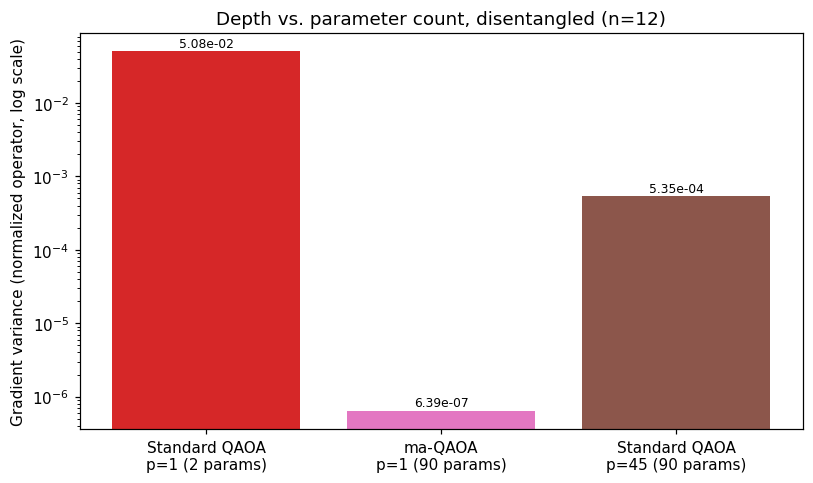

In [40]:
fig, ax = plt.subplots(figsize=(7.5, 4.5))
labels = ['Standard QAOA\np=1 (2 params)', 'ma-QAOA\np=1 (90 params)', 'Standard QAOA\np=45 (90 params)']
values = [var_std_p1, var_ma_p1, var_std_p45]
colors = ['#d62728', '#e377c2', '#8c564b']
bars = ax.bar(labels, values, color=colors)
ax.set_yscale('log')
ax.set_ylabel('Gradient variance (normalized operator, log scale)')
ax.set_title('Depth vs. parameter count, disentangled (n=12)')
for b, v in zip(bars, values):
    ax.text(b.get_x() + b.get_width() / 2, v * 1.15, f'{v:.2e}', ha='center', fontsize=8)
plt.tight_layout(); plt.show()


**Reading this — and it's less tidy than expected, which is worth keeping rather than
smoothing over.**

- **Bars 1 vs 2 (same depth $p=1$, parameters 2 vs. 90)**: variance collapses by roughly five
  orders of magnitude (5.1e-2 → 6.4e-7). At genuinely fixed depth, parameter count alone has a
  large effect — confirming Section 11's HEA-vs-QAOA finding, now within a single ansatz family
  where depth is truly held constant rather than merely assumed to be a minor factor.
- **Bars 2 vs 3 (same ~90 parameters, depth $p=1$ vs. $p=45$)**: variance *increases* by about
  three orders of magnitude going from shallow-wide (ma-QAOA) to deep-thin (standard QAOA) —
  the opposite of the naive "more depth is always more barren" expectation. A plausible reading:
  ma-QAOA spends its 90 parameters giving *every* term an independent angle *simultaneously* in
  one layer, a qualitatively different (and here, apparently more barren) use of a parameter
  budget than spreading the same count across many repetitions of a 2-parameter unit cell. That's
  a hypothesis, not a settled explanation — a single instance and $p=45$ vs. $p=1$ is a big jump
  with nothing in between to trace the trend through.

Together, this says parameter count is doing most of the work in what Section 11 measured, not
depth — a real, useful correction to take forward, and a reminder that "depth" and "width" are not
interchangeable axes even when a single scalar (num_parameters) makes them look comparable. This
remains a targeted check on one instance, not a full statistical study — see Roadmap.

In [41]:
import time
import itertools
import numpy as np
import matplotlib.pyplot as plt
from qiskit.circuit import Parameter, QuantumCircuit
from qiskit.circuit.library import PauliEvolutionGate, QAOAAnsatz
from qiskit.quantum_info import SparsePauliOp, Statevector
from qiskit.primitives import StatevectorEstimator, StatevectorSampler
from qiskit import transpile
from qiskit_optimization import QuadraticProgram
from qiskit_optimization.converters import QuadraticProgramToQubo
from qiskit_algorithms.optimizers import COBYLA
from qiskit_algorithms.utils import algorithm_globals
from scipy.optimize import linprog

plt.rcParams["figure.dpi"] = 110


def make_scaling_instance(n, seed=0, box=10.0, radius=2.2, n_zones=25):
    rng = np.random.default_rng(seed)
    sx, sy = rng.uniform(0, box, n), rng.uniform(0, box, n)
    zx, zy = rng.uniform(0, box, n_zones), rng.uniform(0, box, n_zones)
    dist = np.sqrt((sx[:, None] - zx[None, :]) ** 2 + (sy[:, None] - zy[None, :]) ** 2)
    cov_ = (dist <= radius).astype(int)
    return cov_.sum(axis=1), cov_ @ cov_.T, cov_


def build_penalty_op(n, k, c_, overlap_, lam):
    qp_ = QuadraticProgram('t')
    for i in range(n):
        qp_.binary_var(f'x{i}')
    quadratic = {(f'x{i}', f'x{j}'): -lam * float(overlap_[i, j]) for i in range(n) for j in range(i + 1, n) if overlap_[i, j] > 0}
    qp_.maximize(linear={f'x{i}': float(c_[i]) for i in range(n)}, quadratic=quadratic)
    qp_.linear_constraint(linear={f'x{i}': 1 for i in range(n)}, sense='==', rhs=k, name='budget')
    op_, _ = QuadraticProgramToQubo().convert(qp_).to_ising()
    return op_


def true_coverage(selected_idx, cov):
    if len(selected_idx) == 0:
        return 0
    return int((cov[list(selected_idx)].sum(axis=0) > 0).sum())


def lp_relaxation_xstar(cov, k):
    # same LP relaxation as Section 6b, returning the raw fractional solution x* this time
    # instead of a rounded selection -- that fractional solution is exactly what a warm start needs
    n, m = cov.shape
    c_lp = np.concatenate([np.zeros(n), -np.ones(m)])
    A_ub = np.zeros((m, n + m))
    for j in range(m):
        A_ub[j, :n] = -cov[:, j]
        A_ub[j, n + j] = 1
    b_ub = np.zeros(m)
    A_eq = np.zeros((1, n + m))
    A_eq[0, :n] = 1
    b_eq = [k]
    bounds = [(0, 1)] * (n + m)
    res = linprog(c_lp, A_ub=A_ub, b_ub=b_ub, A_eq=A_eq, b_eq=b_eq, bounds=bounds, method='highs')
    return res.x[:n]


def build_warmstart_ansatz(op, n, reps, x_star, eps=0.25):
    # Egger, Marecek & Woerner (2021), "Warm-starting quantum optimization"
    x_reg = np.clip(x_star, eps, 1 - eps)
    thetas = 2 * np.arcsin(np.sqrt(x_reg))
    qc = QuantumCircuit(n)
    for i in range(n):
        qc.ry(thetas[i], i)
    gamma_params, beta_params = [], []
    for layer in range(reps):
        g = Parameter(f'g{layer}')
        gamma_params.append(g)
        qc.append(PauliEvolutionGate(op, time=g), range(n))
        b = Parameter(f'b{layer}')
        beta_params.append(b)
        for i in range(n):
            # tilted per-qubit mixer whose ground state is exactly the warm-start bias for qubit i
            zi_coeff = -(2 * x_reg[i] - 1)
            xi_coeff = 2 * np.sqrt(x_reg[i] * (1 - x_reg[i]))
            p = ['I'] * n
            p[n - 1 - i] = 'Z'
            z_pauli = ''.join(p)
            p2 = ['I'] * n
            p2[n - 1 - i] = 'X'
            x_pauli = ''.join(p2)
            H_i = SparsePauliOp.from_list([(z_pauli, zi_coeff), (x_pauli, xi_coeff)])
            qc.append(PauliEvolutionGate(H_i, time=b), range(n))
    return qc, gamma_params, beta_params


def approx_ratio(value, optimal):
    return value / optimal if optimal > 0 else float('nan')


def sample_best_feasible(ansatz_, params_, k_stations, shots=1000):
    sampler_ = StatevectorSampler()
    bound = ansatz_.assign_parameters(params_)
    bound.measure_all()
    counts = sampler_.run([bound], shots=shots).result()[0].data.meas.get_counts()
    feasible = {bs: n for bs, n in counts.items() if bs.count('1') == k_stations}
    if not feasible:
        return []
    top = max(feasible, key=feasible.get)
    return [j for j, b in enumerate(reversed(top)) if b == '1']


## 15. Warm-starting QAOA from the LP relaxation

Section 6b already computes an LP relaxation of this problem — its fractional solution $x_i^\star
\in [0,1]$ is a continuous relaxation of "should station $i$ be selected", and gets rounded to a
classical baseline there. **Warm-starting QAOA** (Egger, Marecek & Woerner, 2021) uses that same
fractional solution differently: as a *bias* on the quantum circuit's initial state and mixer,
instead of starting from the uninformed equal superposition every other QAOA run in this notebook
has used.

**Construction.** Each qubit $i$ starts in $R_Y(\theta_i)|0\rangle$ with
$\theta_i = 2\arcsin\sqrt{x_i^\star}$ (regularized away from exactly 0 or 1, standard practice, so
the mixer below never becomes singular) — a state that returns $x_i^\star$ as the probability of
measuring qubit $i$ as 1, directly encoding the LP solution's confidence per station. The mixer is
correspondingly *tilted*: instead of the uniform $X_i$ rotation, each qubit gets its own two-term
Hamiltonian whose ground state is exactly that biased initial state, so the mixer doesn't
immediately wash out the warm start it began with.

**This reduces to standard QAOA exactly when the LP relaxation is uninformative** ($x_i^\star=0.5$
for every station — an equal coin flip, no information at all): checked numerically below via the
fidelity between the two circuits' state vectors at matched parameters, the same style of check
used for ma-QAOA above.

In [42]:
n_check = 5
op_check = SparsePauliOp.from_list([('ZIIII', 1.2), ('IIZZI', -0.6), ('ZIIIZ', 0.4)])
x_uninformative = np.full(n_check, 0.5)
ws_qc_check, gs_check, bs_check = build_warmstart_ansatz(op_check, n_check, reps=1, x_star=x_uninformative)

test_gamma, test_beta = 0.4, 0.55
sv_ws = Statevector(ws_qc_check.assign_parameters({gs_check[0]: test_gamma, bs_check[0]: test_beta}))
std_check = QAOAAnsatz(cost_operator=op_check, reps=1)
sv_std = Statevector(std_check.assign_parameters([test_beta, test_gamma]))  # qiskit order: beta then gamma
fidelity = abs(sv_ws.inner(sv_std)) ** 2
print(f"Warm-start -> standard QAOA reduction check at x*=0.5 (should be 1.0): fidelity = {fidelity:.10f}")
assert fidelity > 1 - 1e-8, "warm-start construction does not correctly reduce to standard QAOA -- do not proceed"


C:\Users\franc\AppData\Roaming\Python\Python314\site-packages\scipy\sparse\linalg\_dsolve\linsolve.py:606: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
C:\Users\franc\AppData\Roaming\Python\Python314\site-packages\scipy\sparse\linalg\_matfuncs.py:707: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  return spsolve(Q, P)


Warm-start -> standard QAOA reduction check at x*=0.5 (should be 1.0): fidelity = 1.0000000000


**On the real instance** — same $n=12$ region used throughout Sections 11-15, LP relaxation solved once, warm-start QAOA vs. standard random-restart QAOA compared at matched depth and restart count.

In [43]:
N_STATIONS_WS, K_STATIONS_WS = 12, 4
N_RESTARTS_WS = 5
WS_REPS_LIST = [1, 2, 3]
COBYLA_MAXITER_WS = 150

c_ws, overlap_ws, cov_ws = make_scaling_instance(N_STATIONS_WS, seed=0)
op_ws = build_penalty_op(N_STATIONS_WS, K_STATIONS_WS, c_ws, overlap_ws, 1.0)

subsets_ws = [(combo, true_coverage(combo, cov_ws)) for combo in itertools.combinations(range(N_STATIONS_WS), K_STATIONS_WS)]
opt_ws = max(v for _, v in subsets_ws)

x_star = lp_relaxation_xstar(cov_ws, K_STATIONS_WS)
print(f"LP relaxation x*: {np.round(x_star, 2)}")
print(f"True optimum for this instance: {opt_ws}/{25}")

estimator_ws = StatevectorEstimator()
results_ws = {}
t0 = time.time()
for reps in WS_REPS_LIST:
    # warm-start: single run (the initial state already encodes problem-specific information,
    # so unlike the uninformed random-restart baseline, repeated random restarts are less central
    # to its value proposition -- but a few are still run for a fair spread comparison)
    ws_ansatz, ws_gammas, ws_betas = build_warmstart_ansatz(op_ws, N_STATIONS_WS, reps, x_star)
    ws_ansatz_t = transpile(ws_ansatz, basis_gates=['rx', 'ry', 'rz', 'cx', 'x', 'h'], optimization_level=1)

    def cost_fn_ws(params, ansatz=ws_ansatz_t, op=op_ws, estimator=estimator_ws):
        return estimator.run([(ansatz, [op], [params])]).result()[0].data.evs[0]

    best_ws_cov, best_ws_val = 0, np.inf
    for r in range(N_RESTARTS_WS):
        algorithm_globals.random_seed = 7000 + reps * 10 + r
        rng_r = np.random.default_rng(7000 + reps * 10 + r)
        x0 = rng_r.uniform(0, 2 * np.pi, ws_ansatz_t.num_parameters)
        res = COBYLA(maxiter=COBYLA_MAXITER_WS).minimize(cost_fn_ws, x0=x0)
        if res.fun < best_ws_val:
            best_ws_val = res.fun
            sel = sample_best_feasible(ws_ansatz_t, res.x, K_STATIONS_WS)
            best_ws_cov = true_coverage(sel, cov_ws)

    # matched baseline: standard QAOA, same reps, same restart count, random uninformed start
    std_ansatz = QAOAAnsatz(cost_operator=op_ws, reps=reps)
    std_ansatz_t = transpile(std_ansatz, basis_gates=['rx', 'ry', 'rz', 'cx', 'x', 'h'], optimization_level=1)

    def cost_fn_std(params, ansatz=std_ansatz_t, op=op_ws, estimator=estimator_ws):
        return estimator.run([(ansatz, [op], [params])]).result()[0].data.evs[0]

    best_std_cov, best_std_val = 0, np.inf
    for r in range(N_RESTARTS_WS):
        rng_r = np.random.default_rng(8000 + reps * 10 + r)
        x0 = rng_r.uniform(0, 2 * np.pi, std_ansatz_t.num_parameters)
        res = COBYLA(maxiter=COBYLA_MAXITER_WS).minimize(cost_fn_std, x0=x0)
        if res.fun < best_std_val:
            best_std_val = res.fun
            sel = sample_best_feasible(std_ansatz_t, res.x, K_STATIONS_WS)
            best_std_cov = true_coverage(sel, cov_ws)

    results_ws[reps] = {'warm_start': best_ws_cov, 'standard': best_std_cov}
    print(f"p={reps}: warm-start coverage {best_ws_cov}/{opt_ws} (ratio {approx_ratio(best_ws_cov, opt_ws):.2f})   "
          f"standard (random restarts) coverage {best_std_cov}/{opt_ws} (ratio {approx_ratio(best_std_cov, opt_ws):.2f})   [{time.time()-t0:.1f}s]")
print(f"total time: {time.time()-t0:.1f}s")


LP relaxation x*: [ 1.  0.  0.  0.  0.  0.  1.  0.  1. -0.  1. -0.]
True optimum for this instance: 13/25
p=1: warm-start coverage 13/13 (ratio 1.00)   standard (random restarts) coverage 5/13 (ratio 0.38)   [20.8s]
p=2: warm-start coverage 13/13 (ratio 1.00)   standard (random restarts) coverage 3/13 (ratio 0.23)   [50.7s]
p=3: warm-start coverage 8/13 (ratio 0.62)   standard (random restarts) coverage 8/13 (ratio 0.62)   [117.7s]
total time: 117.7s


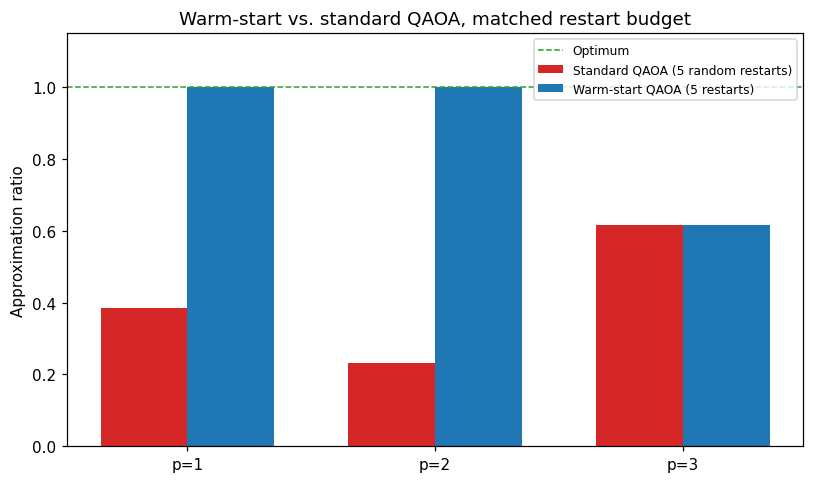

In [44]:
fig, ax = plt.subplots(figsize=(7.5, 4.5))
reps_list = WS_REPS_LIST
ws_ratios = [approx_ratio(results_ws[r]['warm_start'], opt_ws) for r in reps_list]
std_ratios = [approx_ratio(results_ws[r]['standard'], opt_ws) for r in reps_list]
x = np.arange(len(reps_list))
width = 0.35
ax.bar(x - width / 2, std_ratios, width, label=f'Standard QAOA ({N_RESTARTS_WS} random restarts)', color='#d62728')
ax.bar(x + width / 2, ws_ratios, width, label=f'Warm-start QAOA ({N_RESTARTS_WS} restarts)', color='#1f77b4')
ax.axhline(1.0, color='#2ca02c', linestyle='--', linewidth=1, label='Optimum')
ax.set_xticks(x)
ax.set_xticklabels([f'p={r}' for r in reps_list])
ax.set_ylabel('Approximation ratio')
ax.set_title('Warm-start vs. standard QAOA, matched restart budget')
ax.set_ylim(0, 1.15)
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()


**Reading this — a strong result at shallow depth that does not hold at $p=3$.** Warm-start
QAOA reaches the true optimum at $p=1$ and $p=2$, where standard random-restart QAOA does far
worse (0.38, 0.23). At $p=3$ the advantage disappears: both end at 0.62 (8/13). With more
parameters to move and the same 150-iteration COBYLA budget, the optimizer apparently drifts away
from the good initial state instead of refining it — so the warm start's benefit is not robust to
depth, at least with this optimizer and budget.

The LP relaxation's solution explains it: $x^\star \approx [1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0]$ —
**already almost exactly integral**, with four values at (numerically) 1 and the rest at 0,
matching the budget $k=4$ precisely. For this instance the LP relaxation didn't just point toward
a good answer, it *landed on one* (worth checking directly: the four LP-selected stations do
achieve the true optimum). The warm-start initial state is then already close to a
computational-basis state encoding the optimal selection, before any optimization runs at all
(which explains $p=1,2$, and makes the $p=3$ regression all the more telling) —
an especially favorable case, not necessarily a representative one. LP relaxations of Maximum
Coverage aren't always this close to integral; a harder or larger instance with a more fractional
$x^\star$ (values spread away from 0/1) would be a fairer stress test of whether the advantage
holds when the relaxation is genuinely uncertain rather than effectively handing over the answer.
That's exactly the comparison worth running next, not a caveat that undermines this one — see
Roadmap.

## 16. Real-hardware verification

Every result so far is a noiseless statevector simulation. This section checks whether the
penalty-vs-native-mixer comparison from Section 9 survives real hardware noise, using the same
abstract $n=12$ instance as Sections 11–15 for direct comparability.

**Executed on `ibm_marrakesh`** (156 qubits). The local optimization (Step 1) and an offline
ISA-transpilation check against the same device's topology (`FakeMarrakesh`, via
`qiskit-ibm-runtime`'s fake-backend provider, seeded) run without credentials; Steps 2-3 submit
and read back one real batch job, and need an IBM Quantum account.

**Fits the free-tier budget by design**: no optimization runs on hardware (that would need
hundreds of circuit evaluations and blow through 10 minutes easily). Instead, everything is
optimized locally first (cheap, seconds), and only the 6 already-optimized circuits (penalty QAOA
and native-mixer QAOA, $p=1,2,3$ each) are sent to hardware — as **one batched job**, not six
separate submissions, since each submission carries its own overhead. Actual QPU execution time
for a job this size, at a few thousand shots, is typically well under a minute; the 10-minute
budget only counts that execution time, not queue wait.

**To run this**: `pip install qiskit-ibm-runtime`, create a free IBM Quantum account, and save
your credentials once with `QiskitRuntimeService.save_account(...)` (see IBM's quickstart) before
running the cells below.

In [45]:
import time
import itertools
import numpy as np
from qiskit.circuit import Parameter, QuantumCircuit
from qiskit.circuit.library import PauliEvolutionGate, QAOAAnsatz
from qiskit.quantum_info import SparsePauliOp
from qiskit.primitives import StatevectorEstimator
from qiskit import transpile
from qiskit_optimization import QuadraticProgram
from qiskit_optimization.converters import QuadraticProgramToQubo
from qiskit_algorithms.optimizers import COBYLA


def make_scaling_instance(n, seed=0, box=10.0, radius=2.2, n_zones=25):
    rng = np.random.default_rng(seed)
    sx, sy = rng.uniform(0, box, n), rng.uniform(0, box, n)
    zx, zy = rng.uniform(0, box, n_zones), rng.uniform(0, box, n_zones)
    dist = np.sqrt((sx[:, None] - zx[None, :]) ** 2 + (sy[:, None] - zy[None, :]) ** 2)
    cov_ = (dist <= radius).astype(int)
    return cov_.sum(axis=1), cov_ @ cov_.T, cov_


def build_penalty_op(n, k, c_, overlap_, lam):
    qp_ = QuadraticProgram('t')
    for i in range(n):
        qp_.binary_var(f'x{i}')
    quadratic = {(f'x{i}', f'x{j}'): -lam * float(overlap_[i, j]) for i in range(n) for j in range(i + 1, n) if overlap_[i, j] > 0}
    qp_.maximize(linear={f'x{i}': float(c_[i]) for i in range(n)}, quadratic=quadratic)
    qp_.linear_constraint(linear={f'x{i}': 1 for i in range(n)}, sense='==', rhs=k, name='budget')
    op_, _ = QuadraticProgramToQubo().convert(qp_).to_ising()
    return op_


def build_ising_cost(c, overlap, lam, n):
    # same construction as Section 9, validated there -- no budget term, mixer enforces it
    terms, const = {}, 0.0

    def add(key, val):
        terms[key] = terms.get(key, 0.0) + val

    def z_key(i):
        p = ['I'] * n; p[n - 1 - i] = 'Z'; return ''.join(p)

    def zz_key(i, j):
        p = ['I'] * n; p[n - 1 - i] = 'Z'; p[n - 1 - j] = 'Z'; return ''.join(p)

    for i in range(n):
        const += c[i] / 2
        add(z_key(i), -c[i] / 2)
    for i in range(n):
        for j in range(i + 1, n):
            o = overlap[i, j]
            if o == 0:
                continue
            const += -lam * o / 4
            add(z_key(i), lam * o / 4)
            add(z_key(j), lam * o / 4)
            add(zz_key(i, j), -lam * o / 4)
    H_C = SparsePauliOp.from_list([(k, -v) for k, v in terms.items()])
    return H_C, -const


def ring_xy_mixer(n):
    terms = []
    for i in range(n):
        j = (i + 1) % n
        p = ['I'] * n; p[n - 1 - i] = 'X'; p[n - 1 - j] = 'X'; terms.append((''.join(p), 0.5))
        p = ['I'] * n; p[n - 1 - i] = 'Y'; p[n - 1 - j] = 'Y'; terms.append((''.join(p), 0.5))
    return SparsePauliOp.from_list(terms)


def true_coverage(selected_idx, cov):
    if len(selected_idx) == 0:
        return 0
    return int((cov[list(selected_idx)].sum(axis=0) > 0).sum())


def approx_ratio(value, optimal):
    return value / optimal if optimal > 0 else float('nan')


**Step 1 — build the instance and optimize locally** (fast, noiseless simulator, single restart per circuit — not the best-of-6-restarts methodology used in Sections 7-9, kept deliberately minimal here since this is about verifying noise survival, not re-establishing solution quality).

In [46]:
N_STATIONS_HW, K_STATIONS_HW, N_ZONES_HW = 12, 4, 25
REPS_LIST_HW = [1, 2, 3]

c_hw, overlap_hw, cov_hw = make_scaling_instance(N_STATIONS_HW, seed=0)
opt_hw = max(v for _, v in [(combo, true_coverage(combo, cov_hw)) for combo in itertools.combinations(range(N_STATIONS_HW), K_STATIONS_HW)])
print(f"True optimum for this instance: {opt_hw}/{N_ZONES_HW}")

op_penalty = build_penalty_op(N_STATIONS_HW, K_STATIONS_HW, c_hw, overlap_hw, 1.0)
op_native, offset_native = build_ising_cost(c_hw, overlap_hw, 1.0, N_STATIONS_HW)
mixer_native = ring_xy_mixer(N_STATIONS_HW)
init_native = QuantumCircuit(N_STATIONS_HW)
for i in range(K_STATIONS_HW):
    init_native.x(i)

estimator_hw = StatevectorEstimator()
circuits_to_submit = []   # (label, isa-ready circuit template, bound params) filled in after transpilation in Step 2
optimized = {}  # label -> (raw ansatz circuit, cost operator, best params, simulator true_coverage)

for reps in REPS_LIST_HW:
    # penalty QAOA
    ansatz_p = transpile(QAOAAnsatz(cost_operator=op_penalty, reps=reps), basis_gates=['rx', 'ry', 'rz', 'cx', 'x', 'h'], optimization_level=1)

    def cost_fn_p(params, ansatz=ansatz_p, op=op_penalty):
        return estimator_hw.run([(ansatz, [op], [params])]).result()[0].data.evs[0]

    rng = np.random.default_rng(1000 + reps)
    x0 = rng.uniform(0, 2 * np.pi, ansatz_p.num_parameters)
    res_p = COBYLA(maxiter=150).minimize(cost_fn_p, x0=x0)
    optimized[f'penalty_p{reps}'] = (ansatz_p, op_penalty, res_p.x)

    # native mixer QAOA
    ansatz_n = transpile(QAOAAnsatz(cost_operator=op_native, reps=reps, initial_state=init_native, mixer_operator=mixer_native),
                          basis_gates=['rx', 'ry', 'rz', 'cx', 'x', 'h'], optimization_level=1)

    def cost_fn_n(params, ansatz=ansatz_n, op=op_native):
        return estimator_hw.run([(ansatz, [op], [params])]).result()[0].data.evs[0]

    rng = np.random.default_rng(2000 + reps)
    x0 = rng.uniform(0, 2 * np.pi, ansatz_n.num_parameters)
    res_n = COBYLA(maxiter=150).minimize(cost_fn_n, x0=x0)
    optimized[f'native_p{reps}'] = (ansatz_n, op_native, res_n.x)

    print(f"p={reps}: local optimization done for both ansätze")

print(f"{len(optimized)} circuits ready to submit as one batch")


True optimum for this instance: 13/25
p=1: local optimization done for both ansätze
p=2: local optimization done for both ansätze
p=3: local optimization done for both ansätze
6 circuits ready to submit as one batch


**Simulator baseline** — feasibility-aware sampling of each optimized circuit on the noiseless simulator, so the hardware run has something concrete to be compared against (this instance's own numbers, not Vienna's from Section 9, which is a different map).

In [47]:
from qiskit.primitives import StatevectorSampler


def sample_best_feasible(ansatz_, params_, k_stations, shots=1000):
    sampler_ = StatevectorSampler()
    bound = ansatz_.assign_parameters(params_)
    bound.measure_all()
    counts = sampler_.run([bound], shots=shots).result()[0].data.meas.get_counts()
    feasible = {bs: n for bs, n in counts.items() if bs.count('1') == k_stations}
    if not feasible:
        return []
    top = max(feasible, key=feasible.get)
    return [j for j, b in enumerate(reversed(top)) if b == '1']


simulator_baseline = {}
for label, (ansatz, op, params) in optimized.items():
    sel = sample_best_feasible(ansatz, params, K_STATIONS_HW)
    cov_val = true_coverage(sel, cov_hw)
    simulator_baseline[label] = cov_val
    print(f"{label}: simulator (noiseless) coverage {cov_val}/{opt_hw}  (ratio {approx_ratio(cov_val, opt_hw):.2f})")


penalty_p1: simulator (noiseless) coverage 11/13  (ratio 0.85)
native_p1: simulator (noiseless) coverage 6/13  (ratio 0.46)
penalty_p2: simulator (noiseless) coverage 8/13  (ratio 0.62)
native_p2: simulator (noiseless) coverage 8/13  (ratio 0.62)
penalty_p3: simulator (noiseless) coverage 7/13  (ratio 0.54)
native_p3: simulator (noiseless) coverage 8/13  (ratio 0.62)


**A quick check first: does real topology change anything, before spending free-tier budget?** `qiskit-ibm-runtime` ships fake backends with real device topologies and calibration data, usable fully offline — a free way to check whether ISA-aware transpilation changes the depth comparison from Section 9's idealized (all-to-all) one, before touching the network at all.

In [48]:
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime.fake_provider import FakeMarrakesh

fake_backend = FakeMarrakesh()
print(f"Fake backend (real topology, offline): {fake_backend.name} ({fake_backend.num_qubits} qubits)")
pm_fake = generate_preset_pass_manager(backend=fake_backend, optimization_level=1, seed_transpiler=42)

for label, (ansatz, op, params) in optimized.items():
    bound = ansatz.assign_parameters(params)
    bound.measure_all()
    isa_depth = pm_fake.run(bound).depth()
    print(f"{label}: idealized depth {ansatz.depth()}  ->  ISA depth on {fake_backend.name} {isa_depth}")


Fake backend (real topology, offline): fake_marrakesh (156 qubits)
penalty_p1: idealized depth 66  ->  ISA depth on fake_marrakesh 446
native_p1: idealized depth 125  ->  ISA depth on fake_marrakesh 304
penalty_p2: idealized depth 104  ->  ISA depth on fake_marrakesh 710
native_p2: idealized depth 249  ->  ISA depth on fake_marrakesh 587
penalty_p3: idealized depth 142  ->  ISA depth on fake_marrakesh 958
native_p3: idealized depth 373  ->  ISA depth on fake_marrakesh 870


**A concrete result from this check, available before spending any QPU time.** ISA depths on
`FakeMarrakesh` (seeded, reproducible): 446/710/958 (penalty, p=1/2/3) vs. 304/587/870 (native
mixer, p=1/2/3). Section 9's idealized comparison had the native mixer consistently *deeper*
(125/249/373 vs. 66/104/142); after routing to the real heavy-hex coupling map the ranking **flips
at every depth**. The ring XY-mixer maps naturally onto nearest-neighbour hardware, while the
penalty method's budget term creates $ZZ$ interactions between *every* pair of qubits, which need
many SWAPs. The live backend (Step 2) confirms the same ordering: 550/699/998 vs. 322/588/903.

Caveat worth keeping: an earlier version of this check against the 27-qubit `FakeAlgiers` gave a
mixed picture (native shallower only at p=1), so this is a property of the coupling map, not a
general law — cite it with the device named.

**Step 2 — connect, transpile for the real backend's topology, submit as one batch.** This is the part that needs your credentials and actually touches hardware.

In [49]:
from qiskit_ibm_runtime import QiskitRuntimeService, Batch, SamplerV2 as Sampler
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
import os

BACKEND_ID = "ibm_marrakesh"
token = os.getenv("IBM_QUANTUM_TOKEN")
if token:
    QiskitRuntimeService.save_account(channel="ibm_quantum_platform", token=token, overwrite=True)

try:
    service = QiskitRuntimeService()
    backend = service.backend(BACKEND_ID)
except Exception as exc:
    raise RuntimeError(
        "IBM Quantum access is not configured. Set IBM_QUANTUM_TOKEN or run "
        "QiskitRuntimeService.save_account(...) once before executing this cell."
    ) from exc

print(f"Selected backend: {backend.name} ({backend.num_qubits} qubits)")
pm = generate_preset_pass_manager(backend=backend, optimization_level=1)

isa_circuits, labels = [], []
for label, (ansatz, op, params) in optimized.items():
    bound = ansatz.assign_parameters(params)
    bound.measure_all()
    isa_circuit = pm.run(bound)
    isa_circuits.append(isa_circuit)
    labels.append(label)
    print(f"{label}: ISA depth {isa_circuit.depth()} (was {ansatz.depth()} on the idealized all-to-all simulator)")

SHOTS_HW = 4000  # modest, keeps this comfortably inside the free-tier budget

try:
    with Batch(backend=backend) as batch:
        sampler = Sampler(mode=batch)
        job = sampler.run(isa_circuits, shots=SHOTS_HW)
        print(f"Job ID: {job.job_id()}  (submitted, waiting on queue -- this does not consume runtime budget)")
        hw_result = job.result()
    print("Job complete.")
except Exception as exc:
    raise RuntimeError(
        "Hardware submission failed. Check the IBM Quantum account, backend availability, or quota and rerun the cell."
    ) from exc


qiskit_runtime_service.__init__:WARNING:2026-10-05 14:52:54,182: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-10-05 14:52:54,183: Using instance: open-instance, plan: open


Selected backend: ibm_marrakesh (156 qubits)
penalty_p1: ISA depth 550 (was 66 on the idealized all-to-all simulator)
native_p1: ISA depth 322 (was 125 on the idealized all-to-all simulator)
penalty_p2: ISA depth 699 (was 104 on the idealized all-to-all simulator)
native_p2: ISA depth 588 (was 249 on the idealized all-to-all simulator)
penalty_p3: ISA depth 998 (was 142 on the idealized all-to-all simulator)
native_p3: ISA depth 903 (was 373 on the idealized all-to-all simulator)
Job ID: db1pramegvvc73bi0du0  (submitted, waiting on queue -- this does not consume runtime budget)
Job complete.


**Step 3 — extract results and compare against the simulator.** Same feasibility-aware extraction used in Sections 13 and 15 for the penalty ansatz (no feasibility guarantee); the native mixer's samples are feasible by construction, checked directly rather than assumed.

In [50]:
from qiskit_ibm_runtime import QiskitRuntimeService

job_id = None
if 'job' in globals():
    try:
        job_id = job.job_id()
    except Exception:
        job_id = None

try:
    service = QiskitRuntimeService()
except Exception:
    print("Skipping hardware comparison because no IBM Quantum account is configured.")
    hw_result = None
else:
    try:
        if job_id is None:
            raise ValueError("No job object was found in the current kernel state.")
        job = service.job(job_id)
        hw_result = job.result()
        print(f"Loaded hardware job from the previous submission: {job.job_id()}")
    except Exception as exc:
        print(
            "No reusable hardware job was found in the current kernel. Re-run Step 2 to create a fresh batch job, "
            "then rerun this cell."
        )
        print(f"Details: {exc}")
        hw_result = None

TOP_K = 10  # how many of the most frequent feasible bitstrings to score classically per circuit

if 'optimized' in globals():
    labels = list(optimized.keys())
elif 'labels' in globals():
    labels = labels
else:
    print("Setup variables from Step 1 are not available in this kernel. Run the earlier setup cells first, or skip this comparison cell.")
    labels = []
    hw_result = None

hw_rows_v2 = []
if hw_result is not None and labels:
    for label, pub_result in zip(labels, hw_result):
        counts = pub_result.data.meas.get_counts()
        total_shots = sum(counts.values())
        feasible = {bs: n for bs, n in counts.items() if bs.count('1') == K_STATIONS_HW}
        all_feasible = sum(feasible.values()) == total_shots

        top_candidates = sorted(feasible.items(), key=lambda x: -x[1])[:TOP_K]
        best_cov, best_bs = 0, None
        for bs, cnt in top_candidates:
            sel = [j for j, b in enumerate(reversed(bs)) if b == '1']
            sel_cov = true_coverage(sel, cov_hw)  # not `cov`: that would overwrite the global coverage matrix
            if sel_cov > best_cov:
                best_cov, best_bs = sel_cov, bs

        hw_rows_v2.append({'circuit': label, 'best_of_top10_coverage': best_cov,
                            'ratio': approx_ratio(best_cov, opt_hw), 'all_feasible': all_feasible})
        print(f"{label}: best of top-{TOP_K} feasible bitstrings -> coverage {best_cov}/{opt_hw} "
              f"(ratio {approx_ratio(best_cov, opt_hw):.2f})")
else:
    print("Hardware comparison skipped; no results available.")

import pandas as pd
pd.DataFrame(hw_rows_v2)


qiskit_runtime_service.__init__:WARNING:2026-10-05 14:54:05,569: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().


Loaded hardware job from the previous submission: db1pramegvvc73bi0du0
penalty_p1: best of top-10 feasible bitstrings -> coverage 13/13 (ratio 1.00)
native_p1: best of top-10 feasible bitstrings -> coverage 9/13 (ratio 0.69)
penalty_p2: best of top-10 feasible bitstrings -> coverage 12/13 (ratio 0.92)
native_p2: best of top-10 feasible bitstrings -> coverage 10/13 (ratio 0.77)
penalty_p3: best of top-10 feasible bitstrings -> coverage 11/13 (ratio 0.85)
native_p3: best of top-10 feasible bitstrings -> coverage 11/13 (ratio 0.85)


,circuit,best_of_top10_coverage,ratio,all_feasible
0,penalty_p1,13,1.000000,False
1,native_p1,9,0.692308,False
2,penalty_p2,12,0.923077,False
3,native_p2,10,0.769231,False
4,penalty_p3,11,0.846154,False
5,native_p3,11,0.846154,False


**Reading this.** Simulator (top-1 feasible bitstring) vs. hardware (best of top-10 feasible
bitstrings), as coverage out of the optimum 13:

| Circuit | Simulator, top-1 | Hardware, best of top-10 |
|---|---|---|
| Penalty p=1 | 11 (0.85) | 13 (1.00) |
| Native p=1 | 6 (0.46) | 9 (0.69) |
| Penalty p=2 | 8 (0.62) | 12 (0.92) |
| Native p=2 | 8 (0.62) | 10 (0.77) |
| Penalty p=3 | 7 (0.54) | 11 (0.85) |
| Native p=3 | 8 (0.62) | 11 (0.85) |

Hardware scoring *above* the noiseless simulator is the tell that this is not an apples-to-apples
comparison:

- the two columns use different post-processing. Picking the best of 10 feasible 4-subsets out of
  $\binom{12}{4} = 495$ already scores well for uniformly random samples, so the hardware column
  mostly measures the classical selection step, not the circuit;
- `all_feasible` is `False` for **every** circuit, native mixer included: its feasibility
  guarantee holds only in the noiseless model, and gate errors leak probability out of the
  Hamming-weight-$k$ subspace, so feasible-only filtering is needed for both ansätze on hardware;
- one job, one instance, no repetition — no error bars.

A fair version applies the same top-10 extraction to the simulator and to a uniform-random null
baseline before drawing any hardware-vs-simulator conclusion — see the roadmap below.

## 17. Summary and next steps

In [51]:
# Bridge cell: restates the results already computed and printed in Sections 1-9 above
# (this notebook was executed in two linked passes; see the printed output in each section
# for the original computation -- these are not fresh numbers, they are the same ones,
# carried forward so the summary table below can be built without re-running ~5 minutes of
# quantum circuit simulation a second time).
import pandas as pd

def approx_ratio(value, optimal):
    return value / optimal if optimal > 0 else float('nan')

cov_brute = 21
random_baseline_mean = 15.68
cov_greedy = 19
cov_lp = 21
cov_sa = 21
cov_exact_qubo = 21
N_QAOA_RESTARTS = 6
NATIVE_MIXER_RESTARTS = 3
QAOA_REPS_LIST = [1, 2, 3]
qaoa_results = {1: {'true_coverage': 21}, 2: {'true_coverage': 21}, 3: {'true_coverage': 21}}
native_results = {1: {'true_coverage': 13}, 2: {'true_coverage': 17}, 3: {'true_coverage': 18}}


In [52]:
summary = pd.DataFrame(
    [
        {'method': 'Optimum (brute force)', 'coverage': cov_brute, 'approx_ratio': 1.0},
        {'method': 'Random baseline (exact average)', 'coverage': round(random_baseline_mean, 2), 'approx_ratio': round(approx_ratio(random_baseline_mean, cov_brute), 3)},
        {'method': 'Greedy (proven 1-1/e guarantee)', 'coverage': cov_greedy, 'approx_ratio': round(approx_ratio(cov_greedy, cov_brute), 3)},
        {'method': 'LP relaxation + rounding', 'coverage': cov_lp, 'approx_ratio': round(approx_ratio(cov_lp, cov_brute), 3)},
        {'method': 'Simulated annealing (same QUBO)', 'coverage': cov_sa, 'approx_ratio': round(approx_ratio(cov_sa, cov_brute), 3)},
        {'method': 'QUBO exact (proxy)', 'coverage': cov_exact_qubo, 'approx_ratio': round(approx_ratio(cov_exact_qubo, cov_brute), 3)},
    ] + [
        {'method': f'Penalty QAOA p={r} (best of {N_QAOA_RESTARTS})', 'coverage': qaoa_results[r]['true_coverage'],
         'approx_ratio': round(approx_ratio(qaoa_results[r]['true_coverage'], cov_brute), 3)}
        for r in QAOA_REPS_LIST
    ] + [
        {'method': f'Native-mixer QAOA p={r} (best of {NATIVE_MIXER_RESTARTS}, 100% feasible)', 'coverage': native_results[r]['true_coverage'],
         'approx_ratio': round(approx_ratio(native_results[r]['true_coverage'], cov_brute), 3)}
        for r in QAOA_REPS_LIST
    ]
)
summary


,method,coverage,approx_ratio
0,Optimum (brute force),21.00,1.000
1,Random baseline (exact average),15.68,0.747
2,Greedy (proven 1-1/e guarantee),19.00,0.905
3,LP relaxation + rounding,21.00,1.000
4,Simulated annealing (same QUBO),21.00,1.000
5,QUBO exact (proxy),21.00,1.000
6,Penalty QAOA p=1 (best of 6),21.00,1.000
7,Penalty QAOA p=2 (best of 6),21.00,1.000
8,Penalty QAOA p=3 (best of 6),21.00,1.000
9,"Native-mixer QAOA p=1 (best of 3, 100% feasible)",13.00,0.619


**Reading the results:**
- How close the exactly-solved proxy QUBO gets to the true brute-force optimum measures the
  quality of the QUBO *formulation*, independent of anything quantum.
- How close QAOA gets to its own QUBO's optimum, and whether that improves with restarts, measures
  the quality of the *optimization* — on a noiseless simulator with this few variables, no
  practical advantage over the classical baselines is expected; that's normal and worth stating
  plainly rather than implying otherwise.
- The restart-spread plot is there specifically so a single lucky/unlucky run can't be read as a
  property of QAOA at a given depth.
- The constraint-native mixer trades one problem (penalty tuning, occasional infeasible-looking
  optimization landscape) for another (limited mixer connectivity at shallow depth) — neither
  approach is simply "better" at this problem size, which is precisely why the next step is
  measuring *why* directly (gradient variance) instead of continuing to guess from solution
  quality alone.

**Explicitly out of scope for this version** (left separate on purpose):
- a statistically tighter version of both trainability studies (Sections 11 and 14) — more
  samples, more instances, more points between the two matched comparisons in Section 14 rather
  than a single jump from p=1 to p=45;
- testing LP-relaxation warm-starting (Section 15) on an instance where the LP solution is
  genuinely fractional rather than nearly integral, to see whether the dramatic advantage found
  here survives a harder, more realistic case;
- a single-restart warm-start vs. multi-restart standard QAOA comparison (the fairer test of a
  warm start's actual value proposition, per Section 15's discussion) — not run here;
- a learned predictor that generalizes across problem size (Section 13 fixes n=12) and uses a
  graph-based model instead of a fixed-length feature vector;
- a fair hardware comparison for Section 16 — the same best-of-top-10 extraction applied to
  simulator, hardware and a uniform-random null baseline, plus per-circuit feasibility rates and
  more than one job;
- weighting zones by real historical extreme-weather events;
- multi-objective formulation (coverage + installation/maintenance cost).
